In [65]:
# ============================================================
# IMPORT EXPERIMENT MODULE
# ============================================================

from pathlib import Path
import sys
import importlib
import pandas as pd
import numpy as np
import sqlite3

project_root = Path(r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg")

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.experiments.event_training_comparison as etc
importlib.reload(etc)

<module 'src.experiments.event_training_comparison' from 'C:\\Users\\HUGO\\Desktop\\Q8 - NORUEGA\\TFG\\tfg\\src\\experiments\\event_training_comparison.py'>

In [66]:
# ============================================================
# PATHS
# ============================================================

db_path = project_root / "NordPoool" / "data" / "thesis_database.db"

rbatheta_base_path = Path(
    r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\rbaTheta\simulations\all_tests_together"
)

def get_rbatheta_events_path(zone_code, year):
    return rbatheta_base_path / f"{zone_code}_{year}_rbatheta_event_hours.csv"

print("DB exists:", db_path.exists())

DB exists: True


In [117]:
# ============================================================
# EXPERIMENT CONFIGURATION
# ============================================================

zone_code = "NO1"

calibration_start = "2020-01-01"
calibration_end = "2022-12-31"

train_start = "2023-01-01"
train_end = "2023-12-31"

# ============================================================
# TEST WEEKS
# ============================================================

test_weeks = [
    {
        "test_name": "winter_january",
        "test_start": "2024-01-15",
        "test_end": "2024-01-21",
    },
    {
        "test_name": "spring_april",
        "test_start": "2024-04-10",
        "test_end": "2024-04-16",
    },
    {
        "test_name": "summer_june",
        "test_start": "2024-06-24",
        "test_end": "2024-06-30",
    },
    {
        "test_name": "autumn_september",
        "test_start": "2024-09-16",
        "test_end": "2024-09-22",
    },
    {
        "test_name": "winter_december",
        "test_start": "2024-12-02",
        "test_end": "2024-12-08",
    },
]

# Used only for loading all required data at once
test_start = min(week["test_start"] for week in test_weeks)
test_end = max(week["test_end"] for week in test_weeks)

target_horizon = 1

rbatheta_train_year = pd.Timestamp(train_start).year

rbatheta_events_path = get_rbatheta_events_path(
    zone_code=zone_code,
    year=rbatheta_train_year,
)

print("Zone:", zone_code)
print("Calibration:", calibration_start, "to", calibration_end)
print("Train:", train_start, "to", train_end)
print("Test:", test_start, "to", test_end)
print("RBA-Theta year:", rbatheta_train_year)
print("RBA-Theta path:", rbatheta_events_path)
print("RBA-Theta exists:", rbatheta_events_path.exists())

Zone: NO1
Calibration: 2020-01-01 to 2022-12-31
Train: 2023-01-01 to 2023-12-31
Test: 2024-01-15 to 2024-12-08
RBA-Theta year: 2023
RBA-Theta path: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\rbaTheta\simulations\all_tests_together\NO1_2023_rbatheta_event_hours.csv
RBA-Theta exists: False


In [118]:
# ============================================================
# LOAD RAW MARKET TABLES FROM DATABASE
# prices + volumes + flows + capacities as they are
# ============================================================

def get_zone_id(db_path, zone_code):
    query = """
        SELECT zone_id
        FROM BiddingZones
        WHERE zone_code = ?
    """

    with sqlite3.connect(db_path) as conn:
        df = pd.read_sql_query(query, conn, params=[zone_code])

    if df.empty:
        raise ValueError(f"Zone not found: {zone_code}")

    return int(df.loc[0, "zone_id"])


def load_prices_raw(db_path, zone_code, start_date, end_date):
    query = """
        SELECT
            p.price_id,
            p.zone_id,
            bz.zone_code,
            p.delivery_day,
            p.hour,
            p.price_value
        FROM Prices p
        JOIN BiddingZones bz
            ON p.zone_id = bz.zone_id
        WHERE bz.zone_code = ?
          AND p.delivery_day BETWEEN ? AND ?
        ORDER BY p.delivery_day, p.hour
    """

    with sqlite3.connect(db_path) as conn:
        return pd.read_sql_query(
            query,
            conn,
            params=[zone_code, start_date, end_date],
        )


def load_volumes_raw(db_path, zone_code, start_date, end_date):
    query = """
        SELECT
            v.volume_id,
            v.zone_id,
            bz.zone_code,
            v.delivery_day,
            v.hour,
            v.buy_volume_value,
            v.sell_volume_value
        FROM Volumes v
        JOIN BiddingZones bz
            ON v.zone_id = bz.zone_id
        WHERE bz.zone_code = ?
          AND v.delivery_day BETWEEN ? AND ?
        ORDER BY v.delivery_day, v.hour
    """

    with sqlite3.connect(db_path) as conn:
        return pd.read_sql_query(
            query,
            conn,
            params=[zone_code, start_date, end_date],
        )


def load_flows_raw_for_zone(db_path, zone_id, start_date, end_date):
    query = """
        SELECT
            f.flow_id,
            f.from_zone_id,
            bz_from.zone_code AS from_zone_code,
            f.to_zone_id,
            bz_to.zone_code AS to_zone_code,
            f.delivery_day,
            f.hour,
            f.flow_value
        FROM Flows f
        JOIN BiddingZones bz_from
            ON f.from_zone_id = bz_from.zone_id
        JOIN BiddingZones bz_to
            ON f.to_zone_id = bz_to.zone_id
        WHERE f.delivery_day BETWEEN ? AND ?
          AND (f.from_zone_id = ? OR f.to_zone_id = ?)
        ORDER BY f.delivery_day, f.hour, f.from_zone_id, f.to_zone_id
    """

    with sqlite3.connect(db_path) as conn:
        return pd.read_sql_query(
            query,
            conn,
            params=[start_date, end_date, zone_id, zone_id],
        )


def load_capacities_raw_for_zone(db_path, zone_id, start_date, end_date):
    query = """
        SELECT
            c.capacity_id,
            c.from_zone_id,
            bz_from.zone_code AS from_zone_code,
            c.to_zone_id,
            bz_to.zone_code AS to_zone_code,
            c.delivery_day,
            c.hour,
            c.capacity_value
        FROM Capacities c
        JOIN BiddingZones bz_from
            ON c.from_zone_id = bz_from.zone_id
        JOIN BiddingZones bz_to
            ON c.to_zone_id = bz_to.zone_id
        WHERE c.delivery_day BETWEEN ? AND ?
          AND (c.from_zone_id = ? OR c.to_zone_id = ?)
        ORDER BY c.delivery_day, c.hour, c.from_zone_id, c.to_zone_id
    """

    with sqlite3.connect(db_path) as conn:
        return pd.read_sql_query(
            query,
            conn,
            params=[start_date, end_date, zone_id, zone_id],
        )


def add_datetime(df):
    df = df.copy()
    df["delivery_day"] = pd.to_datetime(df["delivery_day"])
    df["datetime"] = df["delivery_day"] + pd.to_timedelta(df["hour"], unit="h")
    return df


global_start = min(calibration_start, train_start, test_start)
global_end = max(calibration_end, train_end, test_end)

zone_id = get_zone_id(db_path, zone_code)

df_prices_raw = load_prices_raw(
    db_path=db_path,
    zone_code=zone_code,
    start_date=global_start,
    end_date=global_end,
)

df_volumes_raw = load_volumes_raw(
    db_path=db_path,
    zone_code=zone_code,
    start_date=global_start,
    end_date=global_end,
)

df_flows_raw = load_flows_raw_for_zone(
    db_path=db_path,
    zone_id=zone_id,
    start_date=global_start,
    end_date=global_end,
)

df_capacities_raw = load_capacities_raw_for_zone(
    db_path=db_path,
    zone_id=zone_id,
    start_date=global_start,
    end_date=global_end,
)

df_prices_raw = add_datetime(df_prices_raw)
df_volumes_raw = add_datetime(df_volumes_raw)
df_flows_raw = add_datetime(df_flows_raw)
df_capacities_raw = add_datetime(df_capacities_raw)

print("Prices:", df_prices_raw.shape)
print("Volumes:", df_volumes_raw.shape)
print("Flows:", df_flows_raw.shape)
print("Capacities:", df_capacities_raw.shape)

print("\nPrices columns:")
print(df_prices_raw.columns.tolist())

print("\nVolumes columns:")
print(df_volumes_raw.columns.tolist())

print("\nFlows columns:")
print(df_flows_raw.columns.tolist())

print("\nCapacities columns:")
print(df_capacities_raw.columns.tolist())

display(df_prices_raw.head())
display(df_volumes_raw.head())
display(df_flows_raw.head())
display(df_capacities_raw.head())

Prices: (43296, 7)
Volumes: (43296, 8)
Flows: (160590, 9)
Capacities: (169324, 9)

Prices columns:
['price_id', 'zone_id', 'zone_code', 'delivery_day', 'hour', 'price_value', 'datetime']

Volumes columns:
['volume_id', 'zone_id', 'zone_code', 'delivery_day', 'hour', 'buy_volume_value', 'sell_volume_value', 'datetime']

Flows columns:
['flow_id', 'from_zone_id', 'from_zone_code', 'to_zone_id', 'to_zone_code', 'delivery_day', 'hour', 'flow_value', 'datetime']

Capacities columns:
['capacity_id', 'from_zone_id', 'from_zone_code', 'to_zone_id', 'to_zone_code', 'delivery_day', 'hour', 'capacity_value', 'datetime']


,price_id,zone_id,zone_code,delivery_day,hour,price_value,datetime
0,657367,7,NO1,2020-01-01,0,31.82,2020-01-01 00:00:00
1,657382,7,NO1,2020-01-01,1,31.77,2020-01-01 01:00:00
2,657397,7,NO1,2020-01-01,2,31.57,2020-01-01 02:00:00
3,657412,7,NO1,2020-01-01,3,31.28,2020-01-01 03:00:00
4,657427,7,NO1,2020-01-01,4,30.72,2020-01-01 04:00:00


,volume_id,zone_id,zone_code,delivery_day,hour,buy_volume_value,sell_volume_value,datetime
0,657367,7,NO1,2020-01-01,0,4176.9,1802.2,2020-01-01 00:00:00
1,657382,7,NO1,2020-01-01,1,4091.8,1819.6,2020-01-01 01:00:00
2,657397,7,NO1,2020-01-01,2,4021.3,1826.2,2020-01-01 02:00:00
3,657412,7,NO1,2020-01-01,3,3975.7,1836.8,2020-01-01 03:00:00
4,657427,7,NO1,2020-01-01,4,3993.6,1841.5,2020-01-01 04:00:00


,flow_id,from_zone_id,from_zone_code,to_zone_id,to_zone_code,delivery_day,hour,flow_value,datetime
0,869155,7,NO1,9,NO3,2020-01-01,0,200.0,2020-01-01 00:00:00
1,869161,11,NO5,7,NO1,2020-01-01,0,1451.7,2020-01-01 00:00:00
2,869168,14,SE3,7,NO1,2020-01-01,0,1123.0,2020-01-01 00:00:00
3,869176,7,NO1,9,NO3,2020-01-01,1,200.0,2020-01-01 01:00:00
4,869182,11,NO5,7,NO1,2020-01-01,1,1377.2,2020-01-01 01:00:00


,capacity_id,from_zone_id,from_zone_code,to_zone_id,to_zone_code,delivery_day,hour,capacity_value,datetime
0,1347982,7,NO1,9,NO3,2020-01-01,0,200.0,2020-01-01 00:00:00
1,1347983,7,NO1,14,SE3,2020-01-01,0,1375.0,2020-01-01 00:00:00
2,1347985,9,NO3,7,NO1,2020-01-01,0,-200.0,2020-01-01 00:00:00
3,1348003,14,SE3,7,NO1,2020-01-01,0,1123.0,2020-01-01 00:00:00
4,1348022,7,NO1,9,NO3,2020-01-01,1,200.0,2020-01-01 01:00:00


In [119]:
# ============================================================
# CREATE MODEL DATASET
# Base table: prices + volumes
# Raw flows/capacities remain loaded separately for event/data usage analysis
# ============================================================

df_market_model = df_prices_raw.merge(
    df_volumes_raw[
        [
            "zone_id",
            "delivery_day",
            "hour",
            "buy_volume_value",
            "sell_volume_value",
        ]
    ],
    on=["zone_id", "delivery_day", "hour"],
    how="left",
)

df_market_model = df_market_model.sort_values("datetime").reset_index(drop=True)

print("Model dataset:", df_market_model.shape)
print("\nMissing values:")
display(df_market_model.isna().sum())

display(df_market_model.head())

Model dataset: (43306, 9)

Missing values:


price_id             0
zone_id              0
zone_code            0
delivery_day         0
hour                 0
price_value          0
datetime             0
buy_volume_value     0
sell_volume_value    0
dtype: int64

,price_id,zone_id,zone_code,delivery_day,hour,price_value,datetime,buy_volume_value,sell_volume_value
0,657367,7,NO1,2020-01-01,0,31.82,2020-01-01 00:00:00,4176.9,1802.2
1,657382,7,NO1,2020-01-01,1,31.77,2020-01-01 01:00:00,4091.8,1819.6
2,657397,7,NO1,2020-01-01,2,31.57,2020-01-01 02:00:00,4021.3,1826.2
3,657412,7,NO1,2020-01-01,3,31.28,2020-01-01 03:00:00,3975.7,1836.8
4,657427,7,NO1,2020-01-01,4,30.72,2020-01-01 04:00:00,3993.6,1841.5


In [120]:
# ============================================================
# PREPARE MODEL DATA
# Split calibration and train once.
# Test weeks will be created later inside the evaluation loop.
# ============================================================

df_model_test = etc.prepare_model_dataset(
    df_prices=df_market_model,
    target_horizon=target_horizon,
)

# Use a temporary test period only to reuse the existing split function.
# The test output from here will not be used for final evaluation.
df_calibration, df_train_full, _ = etc.split_calibration_train_test_periods(
    df_model=df_model_test,

    calibration_start=calibration_start,
    calibration_end=calibration_end,

    train_start=train_start,
    train_end=train_end,

    test_start=test_start,
    test_end=test_end,
)

print("Calibration:", df_calibration.shape)
print("Train:", df_train_full.shape)

print("Calibration period:", df_calibration["datetime"].min(), "to", df_calibration["datetime"].max())
print("Train period:", df_train_full["datetime"].min(), "to", df_train_full["datetime"].max())

display(df_train_full.head())

Calibration: (26316, 13)
Train: (8764, 13)
Calibration period: 2020-01-01 00:00:00 to 2022-12-31 23:00:00
Train period: 2023-01-01 00:00:00 to 2023-12-31 23:00:00


,price_id,zone_id,zone_code,delivery_day,hour,price_value,datetime,buy_volume_value,sell_volume_value,target_price_1h,hour_of_day,day_of_week,month
26319,1051927,7,NO1,2023-01-01,0,119.32,2023-01-01 00:00:00,4206.2,1527.8,108.83,0,6,1
26320,1051942,7,NO1,2023-01-01,1,108.83,2023-01-01 01:00:00,4162.3,1444.6,102.39,1,6,1
26321,1051957,7,NO1,2023-01-01,2,102.39,2023-01-01 02:00:00,4123.0,1342.1,92.36,2,6,1
26322,1051972,7,NO1,2023-01-01,3,92.36,2023-01-01 03:00:00,4130.9,1324.5,82.66,3,6,1
26323,1051987,7,NO1,2023-01-01,4,82.66,2023-01-01 04:00:00,4246.4,1320.6,79.58,4,6,1


In [121]:
# ============================================================
# SPLIT RAW FLOWS AND CAPACITIES INTO PERIODS
# ============================================================

def split_raw_table_by_periods(
    df,
    calibration_start,
    calibration_end,
    train_start,
    train_end,
    test_start,
    test_end,
):
    df = df.copy()
    df["delivery_day"] = pd.to_datetime(df["delivery_day"])

    calibration_start = pd.Timestamp(calibration_start)
    calibration_end = pd.Timestamp(calibration_end)
    train_start = pd.Timestamp(train_start)
    train_end = pd.Timestamp(train_end)
    test_start = pd.Timestamp(test_start)
    test_end = pd.Timestamp(test_end)

    df_calibration_raw = df[
        (df["delivery_day"] >= calibration_start)
        & (df["delivery_day"] <= calibration_end)
    ].copy()

    df_train_raw = df[
        (df["delivery_day"] >= train_start)
        & (df["delivery_day"] <= train_end)
    ].copy()

    df_test_raw = df[
        (df["delivery_day"] >= test_start)
        & (df["delivery_day"] <= test_end)
    ].copy()

    return df_calibration_raw, df_train_raw, df_test_raw


df_flows_calibration, df_flows_train, df_flows_test = split_raw_table_by_periods(
    df=df_flows_raw,
    calibration_start=calibration_start,
    calibration_end=calibration_end,
    train_start=train_start,
    train_end=train_end,
    test_start=test_start,
    test_end=test_end,
)

df_capacities_calibration, df_capacities_train, df_capacities_test = split_raw_table_by_periods(
    df=df_capacities_raw,
    calibration_start=calibration_start,
    calibration_end=calibration_end,
    train_start=train_start,
    train_end=train_end,
    test_start=test_start,
    test_end=test_end,
)

print("Flows calibration:", df_flows_calibration.shape)
print("Flows train:", df_flows_train.shape)
print("Flows test:", df_flows_test.shape)

print("\nCapacities calibration:", df_capacities_calibration.shape)
print("Capacities train:", df_capacities_train.shape)
print("Capacities test:", df_capacities_test.shape)

Flows calibration: (97973, 9)
Flows train: (33578, 9)
Flows test: (27712, 9)

Capacities calibration: (105204, 9)
Capacities train: (35036, 9)
Capacities test: (27740, 9)


In [122]:
# ============================================================
# STEP 1 - SPLIT RAW PRICES AND VOLUMES INTO TRAIN PERIOD
# ============================================================

def filter_raw_table_by_period(df, start_date, end_date):
    df = df.copy()
    df["delivery_day"] = pd.to_datetime(df["delivery_day"])

    start_date = pd.Timestamp(start_date)
    end_date = pd.Timestamp(end_date)

    return df[
        (df["delivery_day"] >= start_date)
        & (df["delivery_day"] <= end_date)
    ].copy()


df_prices_train_raw = filter_raw_table_by_period(
    df=df_prices_raw,
    start_date=train_start,
    end_date=train_end,
)

df_volumes_train_raw = filter_raw_table_by_period(
    df=df_volumes_raw,
    start_date=train_start,
    end_date=train_end,
)

print("Prices train raw:", df_prices_train_raw.shape)
print("Volumes train raw:", df_volumes_train_raw.shape)
print("Flows train raw:", df_flows_train.shape)
print("Capacities train raw:", df_capacities_train.shape)

display(df_prices_train_raw.head())
display(df_volumes_train_raw.head())
display(df_flows_train.head())
display(df_capacities_train.head())

Prices train raw: (8760, 7)
Volumes train raw: (8760, 8)
Flows train raw: (33578, 9)
Capacities train raw: (35036, 9)


,price_id,zone_id,zone_code,delivery_day,hour,price_value,datetime
26304,1051927,7,NO1,2023-01-01,0,119.32,2023-01-01 00:00:00
26305,1051942,7,NO1,2023-01-01,1,108.83,2023-01-01 01:00:00
26306,1051957,7,NO1,2023-01-01,2,102.39,2023-01-01 02:00:00
26307,1051972,7,NO1,2023-01-01,3,92.36,2023-01-01 03:00:00
26308,1051987,7,NO1,2023-01-01,4,82.66,2023-01-01 04:00:00


,volume_id,zone_id,zone_code,delivery_day,hour,buy_volume_value,sell_volume_value,datetime
26304,1051927,7,NO1,2023-01-01,0,4206.2,1527.8,2023-01-01 00:00:00
26305,1051942,7,NO1,2023-01-01,1,4162.3,1444.6,2023-01-01 01:00:00
26306,1051957,7,NO1,2023-01-01,2,4123.0,1342.1,2023-01-01 02:00:00
26307,1051972,7,NO1,2023-01-01,3,4130.9,1324.5,2023-01-01 03:00:00
26308,1051987,7,NO1,2023-01-01,4,4246.4,1320.6,2023-01-01 04:00:00


,flow_id,from_zone_id,from_zone_code,to_zone_id,to_zone_code,delivery_day,hour,flow_value,datetime
97973,1423256,7,NO1,11,NO5,2023-01-01,0,6.0,2023-01-01 00:00:00
97974,1423257,8,NO2,7,NO1,2023-01-01,0,1061.4,2023-01-01 00:00:00
97975,1423259,9,NO3,7,NO1,2023-01-01,0,150.0,2023-01-01 00:00:00
97976,1423267,14,SE3,7,NO1,2023-01-01,0,1473.0,2023-01-01 00:00:00
97977,1423279,7,NO1,11,NO5,2023-01-01,1,197.4,2023-01-01 01:00:00


,capacity_id,from_zone_id,from_zone_code,to_zone_id,to_zone_code,delivery_day,hour,capacity_value,datetime
105204,700734,7,NO1,9,NO3,2023-01-01,0,-150.0,2023-01-01 00:00:00
105205,700735,7,NO1,14,SE3,2023-01-01,0,2017.0,2023-01-01 00:00:00
105206,700737,9,NO3,7,NO1,2023-01-01,0,150.0,2023-01-01 00:00:00
105207,700755,14,SE3,7,NO1,2023-01-01,0,2053.0,2023-01-01 00:00:00
105208,700774,7,NO1,9,NO3,2023-01-01,1,-150.0,2023-01-01 01:00:00


In [123]:
# ============================================================
# STEP 2 - FULL RAW DATA VALUES
# This is the denominator of the data reduction analysis
# ============================================================

full_raw_values = {
    "Dataset": "full_dataset",

    "price_values": int(
        df_prices_train_raw["price_value"].notna().sum()
    ),

    "buy_volume_values": int(
        df_volumes_train_raw["buy_volume_value"].notna().sum()
    ),

    "sell_volume_values": int(
        df_volumes_train_raw["sell_volume_value"].notna().sum()
    ),

    "flow_values": int(
        df_flows_train["flow_value"].notna().sum()
    ),

    "capacity_values": int(
        df_capacities_train["capacity_value"].notna().sum()
    ),
}

full_raw_values["total_raw_values"] = (
    full_raw_values["price_values"]
    + full_raw_values["buy_volume_values"]
    + full_raw_values["sell_volume_values"]
    + full_raw_values["flow_values"]
    + full_raw_values["capacity_values"]
)

full_raw_values

{'Dataset': 'full_dataset',
 'price_values': 8760,
 'buy_volume_values': 8760,
 'sell_volume_values': 8760,
 'flow_values': 33578,
 'capacity_values': 35036,
 'total_raw_values': 94894}

In [124]:
# ============================================================
# STEP 3 - FULL RAW VALUES TABLE
# ============================================================

full_usage_table = pd.DataFrame([full_raw_values])

full_usage_table

,Dataset,price_values,buy_volume_values,sell_volume_values,flow_values,capacity_values,total_raw_values
0,full_dataset,8760,8760,8760,33578,35036,94894


In [125]:
# ============================================================
# CALIBRATE EVENT THRESHOLDS
# Using calibration period only
# ============================================================

# Price thresholds
thresholds_price = etc.calibrate_price_event_thresholds(
    df_calibration=df_calibration
)

thresholds_market = thresholds_price.copy()

# Volume thresholds
thresholds_market["high_buy_volume_p90"] = (
    df_calibration["buy_volume_value"].quantile(0.90)
)

thresholds_market["low_buy_volume_p10"] = (
    df_calibration["buy_volume_value"].quantile(0.10)
)

thresholds_market["high_sell_volume_p90"] = (
    df_calibration["sell_volume_value"].quantile(0.90)
)

thresholds_market["low_sell_volume_p10"] = (
    df_calibration["sell_volume_value"].quantile(0.10)
)

# Flow thresholds
thresholds_market["high_abs_flow_p90"] = (
    df_flows_calibration["flow_value"].abs().quantile(0.90)
)

# Capacity thresholds
thresholds_market["low_capacity_p10"] = (
    df_capacities_calibration["capacity_value"].quantile(0.10)
)

thresholds_market

{'low_price': np.float64(2.97),
 'high_price': np.float64(204.95499999999998),
 'extreme_price': np.float64(290.00250000000005),
 'price_spike': np.float64(5.030000000000001),
 'rapid_price_change': np.float64(22.305999999999983),
 'price_ramp_up': np.float64(11.782999999999983),
 'price_ramp_down': np.float64(-11.660000000000025),
 'high_volatility': np.float64(36.45901071877775),
 'high_buy_volume_p90': np.float64(5818.7),
 'low_buy_volume_p10': np.float64(2085.05),
 'high_sell_volume_p90': np.float64(3045.95),
 'low_sell_volume_p10': np.float64(1371.45),
 'high_abs_flow_p90': np.float64(2098.0800000000004),
 'low_capacity_p10': np.float64(-200.0)}

In [126]:
# ============================================================
# STEP 4 - OWN EVENT VALUES BY VARIABLE TYPE
# Count values selected by each event detector, not event hours
# ============================================================

# ------------------------------------------------------------
# 1. Price event values
# ------------------------------------------------------------

df_train_price_events, price_event_cols = etc.apply_calibrated_price_events(
    df=df_train_full,
    thresholds=thresholds_price,
)

df_train_price_events["has_price_event"] = (
    df_train_price_events[price_event_cols].any(axis=1)
)

own_price_values = int(
    df_train_price_events.loc[
        df_train_price_events["has_price_event"],
        "price_value"
    ].notna().sum()
)


# ------------------------------------------------------------
# 2. Buy volume event values
# ------------------------------------------------------------

df_train_volume_events = df_train_full.copy()

df_train_volume_events["high_buy_volume"] = (
    df_train_volume_events["buy_volume_value"]
    > thresholds_market["high_buy_volume_p90"]
)

df_train_volume_events["low_buy_volume"] = (
    df_train_volume_events["buy_volume_value"]
    < thresholds_market["low_buy_volume_p10"]
)

df_train_volume_events["has_buy_volume_event"] = (
    df_train_volume_events[
        [
            "high_buy_volume",
            "low_buy_volume",
        ]
    ].any(axis=1)
)

own_buy_volume_values = int(
    df_train_volume_events.loc[
        df_train_volume_events["has_buy_volume_event"],
        "buy_volume_value"
    ].notna().sum()
)


# ------------------------------------------------------------
# 3. Sell volume event values
# ------------------------------------------------------------

df_train_volume_events["high_sell_volume"] = (
    df_train_volume_events["sell_volume_value"]
    > thresholds_market["high_sell_volume_p90"]
)

df_train_volume_events["low_sell_volume"] = (
    df_train_volume_events["sell_volume_value"]
    < thresholds_market["low_sell_volume_p10"]
)

df_train_volume_events["has_sell_volume_event"] = (
    df_train_volume_events[
        [
            "high_sell_volume",
            "low_sell_volume",
        ]
    ].any(axis=1)
)

own_sell_volume_values = int(
    df_train_volume_events.loc[
        df_train_volume_events["has_sell_volume_event"],
        "sell_volume_value"
    ].notna().sum()
)


# ------------------------------------------------------------
# 4. Flow event values
# ------------------------------------------------------------

df_flow_events_train = df_flows_train.copy()

df_flow_events_train["high_abs_flow_event"] = (
    df_flow_events_train["flow_value"].abs()
    > thresholds_market["high_abs_flow_p90"]
)

own_flow_values = int(
    df_flow_events_train.loc[
        df_flow_events_train["high_abs_flow_event"],
        "flow_value"
    ].notna().sum()
)


# ------------------------------------------------------------
# 5. Capacity event values
# ------------------------------------------------------------

df_capacity_events_train = df_capacities_train.copy()

df_capacity_events_train["low_capacity_event"] = (
    df_capacity_events_train["capacity_value"]
    < thresholds_market["low_capacity_p10"]
)

own_capacity_values = int(
    df_capacity_events_train.loc[
        df_capacity_events_train["low_capacity_event"],
        "capacity_value"
    ].notna().sum()
)


# ------------------------------------------------------------
# 6. Summary
# ------------------------------------------------------------

own_event_values = {
    "Dataset": "own_events",

    "price_values": own_price_values,
    "buy_volume_values": own_buy_volume_values,
    "sell_volume_values": own_sell_volume_values,
    "flow_values": own_flow_values,
    "capacity_values": own_capacity_values,
}

own_event_values["total_raw_values"] = (
    own_event_values["price_values"]
    + own_event_values["buy_volume_values"]
    + own_event_values["sell_volume_values"]
    + own_event_values["flow_values"]
    + own_event_values["capacity_values"]
)

own_event_values

{'Dataset': 'own_events',
 'price_values': 2456,
 'buy_volume_values': 2439,
 'sell_volume_values': 716,
 'flow_values': 3332,
 'capacity_values': 555,
 'total_raw_values': 9498}

In [127]:
# ============================================================
# STEP 5 - DATA USAGE COMPARISON TABLE
# Values, not hours
# ============================================================

data_usage_table = pd.DataFrame([
    full_raw_values,
    own_event_values,
])

data_usage_table["Raw values used (%)"] = (
    data_usage_table["total_raw_values"]
    / full_raw_values["total_raw_values"]
    * 100
)

data_usage_table["Raw value reduction (%)"] = (
    100 - data_usage_table["Raw values used (%)"]
)

data_usage_table

,Dataset,price_values,buy_volume_values,sell_volume_values,flow_values,capacity_values,total_raw_values,Raw values used (%),Raw value reduction (%)
0,full_dataset,8760,8760,8760,33578,35036,94894,100.000000,0.000000
1,own_events,2456,2439,716,3332,555,9498,10.009063,89.990937


In [128]:
# ============================================================
# STEP 6 - RBA-THETA EVENT VALUES FROM INDIVIDUAL FILES
# Each row in each rbaTheta event CSV is one detected value
# ============================================================

from pathlib import Path

rbatheta_year = pd.Timestamp(train_start).year

def find_rbatheta_event_files(rbatheta_base_path, zone_code, year):
    files = []

    for path in Path(rbatheta_base_path).glob(f"*{year}*rbatheta_event*.csv"):
        name = path.name.lower()

        # Keep event files only, ignore mcmc files
        if "mcmc" in name:
            continue

        # Keep files related to the target zone.
        # This captures:
        # NO1_buy_volume...
        # NO1_sell_volume...
        # NO1_to_NO2_flow...
        # NO2_to_NO1_flow...
        # NO1_to_NO3_capacity...
        # NO3_to_NO1_capacity...
        if (
            name.startswith(zone_code.lower())
            or f"_{zone_code.lower()}_" in name
            or f"_to_{zone_code.lower()}_" in name
            or f"{zone_code.lower()}_to_" in name
        ):
            files.append(path)

    return sorted(files)


rbatheta_event_files = find_rbatheta_event_files(
    rbatheta_base_path=rbatheta_base_path,
    zone_code=zone_code,
    year=rbatheta_year,
)

print("rbaTheta event files found:", len(rbatheta_event_files))

for f in rbatheta_event_files[:20]:
    print(f.name)

rbaTheta event files found: 15
NO1_buy_volume_2023_rbatheta_event_hours.csv
NO1_price_2023_rbatheta_event_hours.csv
NO1_sell_volume_2023_rbatheta_event_hours.csv
NO1_to_NO2_flow_2023_rbatheta_event_hours.csv
NO1_to_NO3_capacity_2023_rbatheta_event_hours.csv
NO1_to_NO3_flow_2023_rbatheta_event_hours.csv
NO1_to_NO5_flow_2023_rbatheta_event_hours.csv
NO1_to_SE3_capacity_2023_rbatheta_event_hours.csv
NO1_to_SE3_flow_2023_rbatheta_event_hours.csv
NO2_to_NO1_flow_2023_rbatheta_event_hours.csv
NO3_to_NO1_capacity_2023_rbatheta_event_hours.csv
NO3_to_NO1_flow_2023_rbatheta_event_hours.csv
NO5_to_NO1_flow_2023_rbatheta_event_hours.csv
SE3_to_NO1_capacity_2023_rbatheta_event_hours.csv
SE3_to_NO1_flow_2023_rbatheta_event_hours.csv


In [129]:
# ============================================================
# STEP 7 - CLASSIFY RBA-THETA EVENT FILES BY DATA TYPE
# ============================================================

def classify_rbatheta_file(path):
    name = path.name.lower()

    if "price" in name:
        return "price_values"

    if "buy" in name and ("vol" in name or "volume" in name):
        return "buy_volume_values"

    if "sell" in name and ("vol" in name or "volume" in name):
        return "sell_volume_values"

    if "flow" in name:
        return "flow_values"

    if "capacity" in name or "capacit" in name:
        return "capacity_values"

    return "unknown"


file_classification = []

for path in rbatheta_event_files:
    file_classification.append({
        "file": path.name,
        "value_type": classify_rbatheta_file(path),
    })

rbatheta_file_types = pd.DataFrame(file_classification)

display(rbatheta_file_types)

print("File types:")
display(rbatheta_file_types["value_type"].value_counts())

,file,value_type
0,NO1_buy_volume_2023_rbatheta_event_hours.csv,buy_volume_values
1,NO1_price_2023_rbatheta_event_hours.csv,price_values
2,NO1_sell_volume_2023_rbatheta_event_hours.csv,sell_volume_values
3,NO1_to_NO2_flow_2023_rbatheta_event_hours.csv,flow_values
4,NO1_to_NO3_capacity_2023_rbatheta_event_hours.csv,capacity_values
5,NO1_to_NO3_flow_2023_rbatheta_event_hours.csv,flow_values
6,NO1_to_NO5_flow_2023_rbatheta_event_hours.csv,flow_values
7,NO1_to_SE3_capacity_2023_rbatheta_event_hours.csv,capacity_values
8,NO1_to_SE3_flow_2023_rbatheta_event_hours.csv,flow_values
9,NO2_to_NO1_flow_2023_rbatheta_event_hours.csv,flow_values


File types:


value_type
flow_values           8
capacity_values       4
buy_volume_values     1
price_values          1
sell_volume_values    1
Name: count, dtype: int64

In [130]:
# ============================================================
# STEP 8 - COUNT RBA-THETA DETECTED VALUES
# Each row = one detected value
# ============================================================

rbatheta_rows = []

for path in rbatheta_event_files:
    value_type = classify_rbatheta_file(path)

    if value_type == "unknown":
        print("Skipping unknown file:", path.name)
        continue

    df_tmp = pd.read_csv(path)

    # Normalize datetime if available
    if "datetime" in df_tmp.columns:
        df_tmp["datetime"] = pd.to_datetime(df_tmp["datetime"], errors="coerce")

        # Keep only train period, just in case
        df_tmp = df_tmp[
            (df_tmp["datetime"] >= pd.Timestamp(train_start))
            & (df_tmp["datetime"] <= pd.Timestamp(train_end) + pd.Timedelta(hours=23))
        ].copy()

    # Try to identify series name
    if "series_name" in df_tmp.columns:
        series_name = df_tmp["series_name"].dropna().astype(str).iloc[0] if len(df_tmp) > 0 else path.stem
    elif "zone_code" in df_tmp.columns:
        series_name = df_tmp["zone_code"].dropna().astype(str).iloc[0] if len(df_tmp) > 0 else path.stem
    else:
        series_name = path.stem

    # Avoid duplicate events for the same series and datetime
    if "datetime" in df_tmp.columns:
        n_values = (
            df_tmp
            .drop_duplicates(subset=["datetime"])
            .shape[0]
        )
    else:
        n_values = len(df_tmp)

    rbatheta_rows.append({
        "file": path.name,
        "series_name": series_name,
        "value_type": value_type,
        "detected_values": int(n_values),
    })

rbatheta_file_counts = pd.DataFrame(rbatheta_rows)

display(rbatheta_file_counts)

print("rbaTheta values by type:")
display(
    rbatheta_file_counts
    .groupby("value_type")["detected_values"]
    .sum()
)

,file,series_name,value_type,detected_values
0,NO1_buy_volume_2023_rbatheta_event_hours.csv,NO1_buy_volume,buy_volume_values,5219
1,NO1_price_2023_rbatheta_event_hours.csv,NO1,price_values,4770
2,NO1_sell_volume_2023_rbatheta_event_hours.csv,NO1_sell_volume,sell_volume_values,5440
3,NO1_to_NO2_flow_2023_rbatheta_event_hours.csv,NO1_to_NO2_flow,flow_values,3648
4,NO1_to_NO3_capacity_2023_rbatheta_event_hours.csv,NO1_to_NO3_capacity_2023_rbatheta_event_hours,capacity_values,0
5,NO1_to_NO3_flow_2023_rbatheta_event_hours.csv,NO1_to_NO3_flow_2023_rbatheta_event_hours,flow_values,0
6,NO1_to_NO5_flow_2023_rbatheta_event_hours.csv,NO1_to_NO5_flow,flow_values,754
7,NO1_to_SE3_capacity_2023_rbatheta_event_hours.csv,NO1_to_SE3_capacity_2023_rbatheta_event_hours,capacity_values,0
8,NO1_to_SE3_flow_2023_rbatheta_event_hours.csv,NO1_to_SE3_flow,flow_values,3331
9,NO2_to_NO1_flow_2023_rbatheta_event_hours.csv,NO2_to_NO1_flow,flow_values,2454


rbaTheta values by type:


value_type
buy_volume_values      5219
capacity_values           0
flow_values           19731
price_values           4770
sell_volume_values     5440
Name: detected_values, dtype: int64

In [131]:
# ============================================================
# STEP 9 - RBA-THETA DATA USAGE COUNTS
# Values detected by rbaTheta, not event hours
# ============================================================

rbatheta_counts = (
    rbatheta_file_counts
    .groupby("value_type")["detected_values"]
    .sum()
)

rbatheta_event_values = {
    "Dataset": "rbatheta_events",

    "price_values": int(rbatheta_counts.get("price_values", 0)),
    "buy_volume_values": int(rbatheta_counts.get("buy_volume_values", 0)),
    "sell_volume_values": int(rbatheta_counts.get("sell_volume_values", 0)),
    "flow_values": int(rbatheta_counts.get("flow_values", 0)),
    "capacity_values": int(rbatheta_counts.get("capacity_values", 0)),
}

rbatheta_event_values["total_raw_values"] = (
    rbatheta_event_values["price_values"]
    + rbatheta_event_values["buy_volume_values"]
    + rbatheta_event_values["sell_volume_values"]
    + rbatheta_event_values["flow_values"]
    + rbatheta_event_values["capacity_values"]
)

rbatheta_event_values

{'Dataset': 'rbatheta_events',
 'price_values': 4770,
 'buy_volume_values': 5219,
 'sell_volume_values': 5440,
 'flow_values': 19731,
 'capacity_values': 0,
 'total_raw_values': 35160}

In [132]:
# ============================================================
# STEP 10 - FINAL DATA USAGE TABLE
# full_dataset vs own_events vs rbatheta_events
# ============================================================

data_usage_table = pd.DataFrame([
    full_raw_values,
    own_event_values,
    rbatheta_event_values,
])

data_usage_table["Raw values used (%)"] = (
    data_usage_table["total_raw_values"]
    / full_raw_values["total_raw_values"]
    * 100
)

data_usage_table["Raw value reduction (%)"] = (
    100 - data_usage_table["Raw values used (%)"]
)

data_usage_table = data_usage_table[
    [
        "Dataset",
        "price_values",
        "buy_volume_values",
        "sell_volume_values",
        "flow_values",
        "capacity_values",
        "total_raw_values",
        "Raw values used (%)",
        "Raw value reduction (%)",
    ]
]

data_usage_table

,Dataset,price_values,buy_volume_values,sell_volume_values,flow_values,capacity_values,total_raw_values,Raw values used (%),Raw value reduction (%)
0,full_dataset,8760,8760,8760,33578,35036,94894,100.000000,0.000000
1,own_events,2456,2439,716,3332,555,9498,10.009063,89.990937
2,rbatheta_events,4770,5219,5440,19731,0,35160,37.051868,62.948132


In [133]:
# ============================================================
# STEP 11 - BUILD TRAINING DATASETS FOR PERFORMANCE
# ============================================================

# ------------------------------------------------------------
# 1. Full dataset
# ------------------------------------------------------------

df_train_full_final = df_train_full.copy()


# ------------------------------------------------------------
# 2. rbaTheta dataset from individual event files
# ------------------------------------------------------------

def build_rbatheta_train_dataset_from_event_files(
    df_train_full,
    rbatheta_event_files,
    train_start,
    train_end,
):
    event_hours_list = []

    for path in rbatheta_event_files:
        df_tmp = pd.read_csv(path)

        if "datetime" not in df_tmp.columns:
            print("Skipping file without datetime:", path.name)
            continue

        df_tmp["datetime"] = pd.to_datetime(
            df_tmp["datetime"],
            errors="coerce",
            dayfirst=True,
        )

        df_tmp = df_tmp.dropna(subset=["datetime"])

        df_tmp = df_tmp[
            (df_tmp["datetime"] >= pd.Timestamp(train_start))
            & (df_tmp["datetime"] <= pd.Timestamp(train_end) + pd.Timedelta(hours=23))
        ].copy()

        if df_tmp.empty:
            continue

        df_tmp["delivery_day"] = df_tmp["datetime"].dt.floor("D")
        df_tmp["hour"] = df_tmp["datetime"].dt.hour

        event_hours_list.append(
            df_tmp[["delivery_day", "hour"]]
        )

    if len(event_hours_list) == 0:
        raise ValueError("No rbaTheta event hours found from individual files.")

    df_rbatheta_event_hours = (
        pd.concat(event_hours_list, ignore_index=True)
        .drop_duplicates()
    )

    df_train = df_train_full.copy()
    df_train["delivery_day"] = pd.to_datetime(df_train["delivery_day"])

    df_rbatheta_train = df_train.merge(
        df_rbatheta_event_hours,
        on=["delivery_day", "hour"],
        how="inner",
    )

    return df_rbatheta_train, df_rbatheta_event_hours


df_train_rbatheta, df_rbatheta_event_hours = build_rbatheta_train_dataset_from_event_files(
    df_train_full=df_train_full,
    rbatheta_event_files=rbatheta_event_files,
    train_start=train_start,
    train_end=train_end,
)

print("rbaTheta event hours:", len(df_rbatheta_event_hours))
print("rbaTheta training rows:", df_train_rbatheta.shape)


# ------------------------------------------------------------
# 3. Own events dataset
# For training we still need rows, so we select hours where at least one own detector fired.
# This is only for model training, not for the data-usage table.
# ------------------------------------------------------------

own_event_hours_parts = []

# Price event hours
own_event_hours_parts.append(
    df_train_price_events.loc[
        df_train_price_events["has_price_event"],
        ["delivery_day", "hour"]
    ]
)

# Buy volume event hours
own_event_hours_parts.append(
    df_train_volume_events.loc[
        df_train_volume_events["has_buy_volume_event"],
        ["delivery_day", "hour"]
    ]
)

# Sell volume event hours
own_event_hours_parts.append(
    df_train_volume_events.loc[
        df_train_volume_events["has_sell_volume_event"],
        ["delivery_day", "hour"]
    ]
)

# Flow event hours
df_flow_hours = df_flow_events_train.loc[
    df_flow_events_train["high_abs_flow_event"],
    ["delivery_day", "hour"]
].copy()

own_event_hours_parts.append(df_flow_hours)

# Capacity event hours
df_capacity_hours = df_capacity_events_train.loc[
    df_capacity_events_train["low_capacity_event"],
    ["delivery_day", "hour"]
].copy()

own_event_hours_parts.append(df_capacity_hours)

df_own_event_hours = (
    pd.concat(own_event_hours_parts, ignore_index=True)
    .drop_duplicates()
)

df_own_event_hours["delivery_day"] = pd.to_datetime(
    df_own_event_hours["delivery_day"]
)

df_train_full_aux = df_train_full.copy()
df_train_full_aux["delivery_day"] = pd.to_datetime(
    df_train_full_aux["delivery_day"]
)

df_train_own = df_train_full_aux.merge(
    df_own_event_hours,
    on=["delivery_day", "hour"],
    how="inner",
)


# ------------------------------------------------------------
# 4. Final training datasets
# Names kept for compatibility with etc.build_results_table
# ------------------------------------------------------------

train_datasets = {
    "full_prices": df_train_full_final,
    "rbatheta_events": df_train_rbatheta,
    "own_events": df_train_own,
}

print("\nTraining datasets:")
for name, df in train_datasets.items():
    print(name, df.shape)

rbaTheta event hours: 5701
rbaTheta training rows: (5701, 13)

Training datasets:
full_prices (8764, 13)
rbatheta_events (5701, 13)
own_events (6049, 13)


C:\Users\HUGO\AppData\Local\Temp\ipykernel_8972\795516161.py:31: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_tmp["datetime"] = pd.to_datetime(


In [134]:
# ============================================================
# HELPER - BUILD TEST DATASET FOR ONE WEEK
# ============================================================

def build_test_week_dataset(df_model, test_start, test_end):
    test_start_ts = pd.Timestamp(test_start)
    test_end_ts = pd.Timestamp(test_end + " 23:00:00")

    df_test_week = df_model[
        (df_model["datetime"] >= test_start_ts)
        & (df_model["datetime"] <= test_end_ts)
    ].copy()

    return df_test_week

Saving experiment in:
C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\results\event_training_comparison\NO1_cal20200101-20221231_train20230101-20231231_5weeks2024_raw_values_event_comparison

Evaluating test week: winter_january
Period: 2024-01-15 to 2024-01-21
Test shape: (168, 13)
Training model: Linear Regression
Training model: Decision Tree
Training model: Random Forest
Training model: XGBoost
Training model: ARIMA


,Test week,Test period,Model,Dataset,total_raw_values,Raw values used (%),Raw value reduction (%),RMSE,RMSLE
0,winter_january,2024-01-15 to 2024-01-21,ARIMA,own_events,9498,10.009063,89.990937,10.854548,0.083745
1,winter_january,2024-01-15 to 2024-01-21,ARIMA,rbatheta_events,35160,37.051868,62.948132,10.683991,0.081211
2,winter_january,2024-01-15 to 2024-01-21,ARIMA,full_dataset,94894,100.000000,0.000000,10.520979,0.081352
3,winter_january,2024-01-15 to 2024-01-21,Decision Tree,own_events,9498,10.009063,89.990937,30.643171,0.330797
4,winter_january,2024-01-15 to 2024-01-21,Decision Tree,rbatheta_events,35160,37.051868,62.948132,27.205765,0.368877
5,winter_january,2024-01-15 to 2024-01-21,Decision Tree,full_dataset,94894,100.000000,0.000000,33.605097,0.476143
6,winter_january,2024-01-15 to 2024-01-21,Linear Regression,own_events,9498,10.009063,89.990937,13.067490,0.108797
7,winter_january,2024-01-15 to 2024-01-21,Linear Regression,rbatheta_events,35160,37.051868,62.948132,12.761303,0.101850
8,winter_january,2024-01-15 to 2024-01-21,Linear Regression,full_dataset,94894,100.000000,0.000000,12.780653,0.101818
9,winter_january,2024-01-15 to 2024-01-21,Random Forest,own_events,9498,10.009063,89.990937,17.288377,0.187669


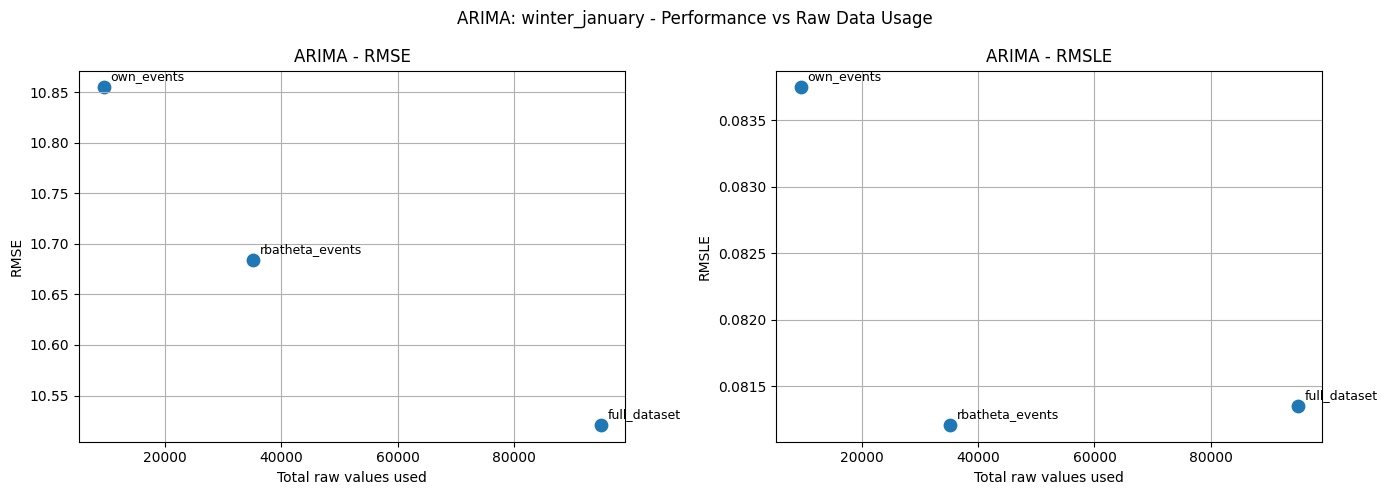

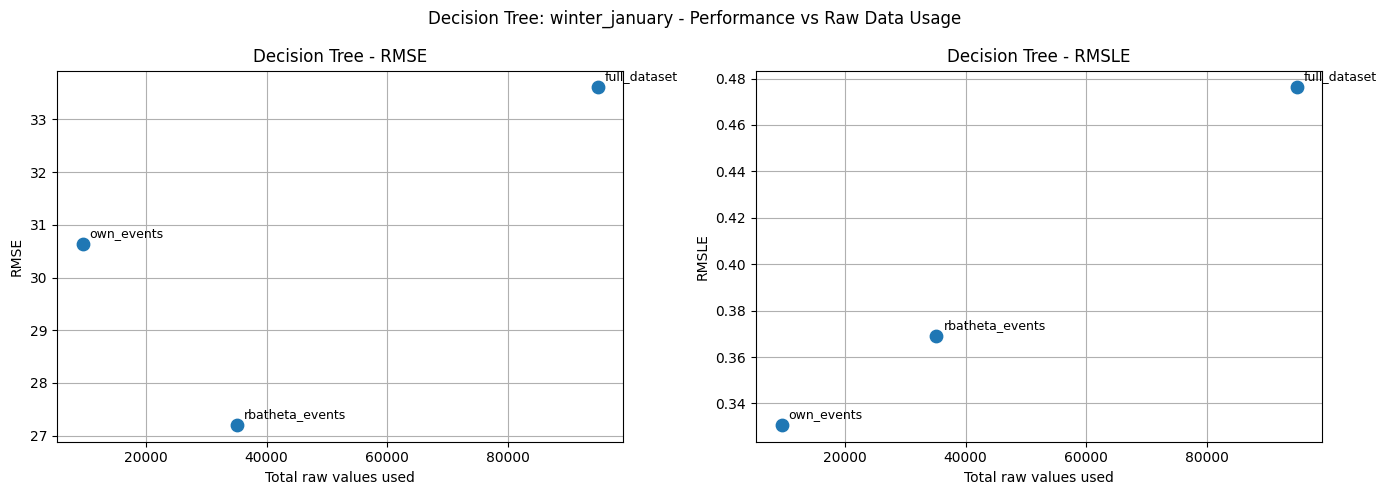

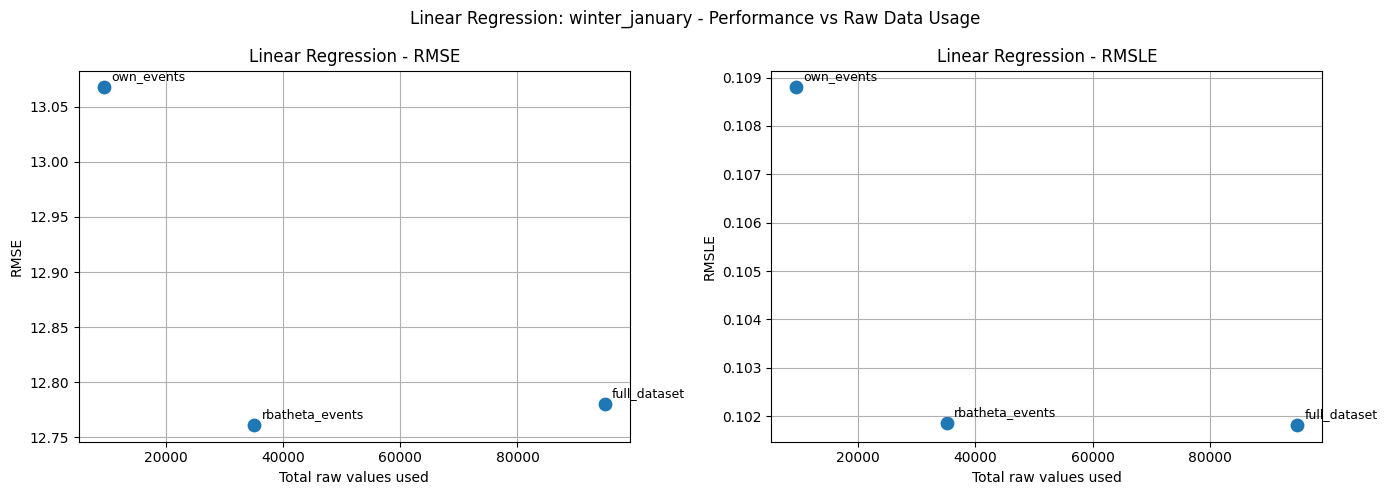

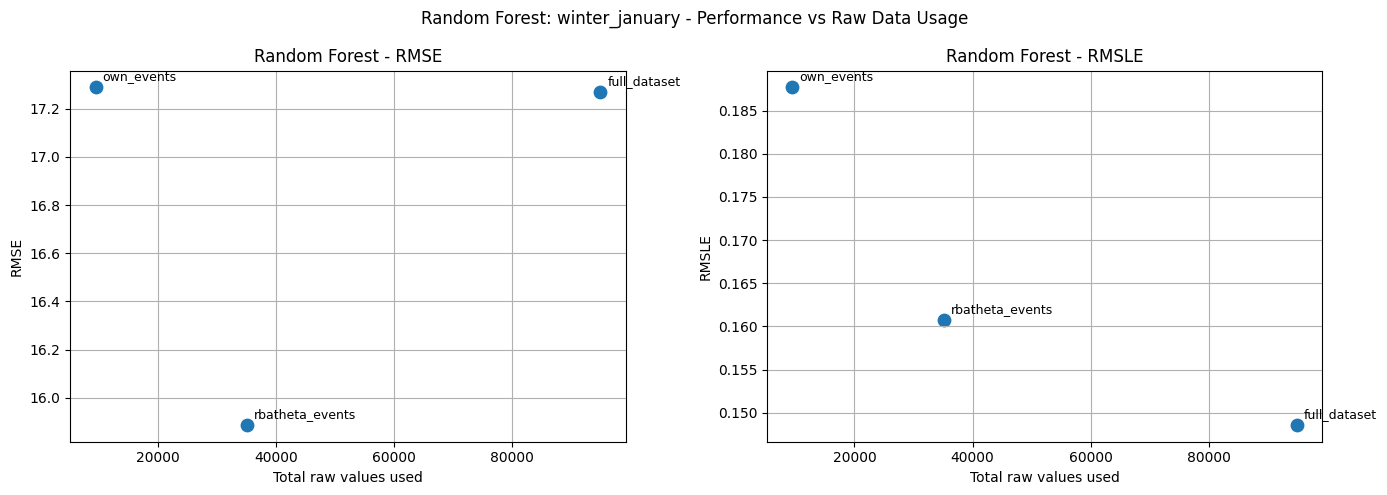

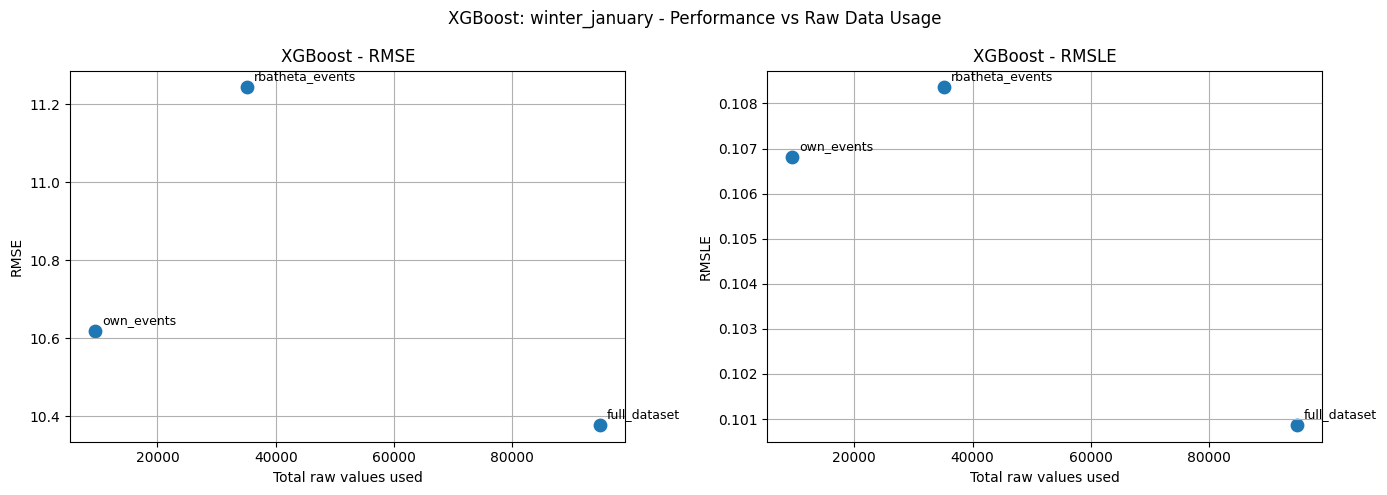


Evaluating test week: spring_april
Period: 2024-04-10 to 2024-04-16
Test shape: (168, 13)
Training model: Linear Regression
Training model: Decision Tree
Training model: Random Forest
Training model: XGBoost
Training model: ARIMA


,Test week,Test period,Model,Dataset,total_raw_values,Raw values used (%),Raw value reduction (%),RMSE,RMSLE
0,spring_april,2024-04-10 to 2024-04-16,ARIMA,own_events,9498,10.009063,89.990937,10.435965,0.559670
1,spring_april,2024-04-10 to 2024-04-16,ARIMA,rbatheta_events,35160,37.051868,62.948132,11.277172,0.568590
2,spring_april,2024-04-10 to 2024-04-16,ARIMA,full_dataset,94894,100.000000,0.000000,10.370829,0.558600
3,spring_april,2024-04-10 to 2024-04-16,Decision Tree,own_events,9498,10.009063,89.990937,19.164291,0.879249
4,spring_april,2024-04-10 to 2024-04-16,Decision Tree,rbatheta_events,35160,37.051868,62.948132,19.863700,0.804876
5,spring_april,2024-04-10 to 2024-04-16,Decision Tree,full_dataset,94894,100.000000,0.000000,20.346175,0.995939
6,spring_april,2024-04-10 to 2024-04-16,Linear Regression,own_events,9498,10.009063,89.990937,10.788350,0.607678
7,spring_april,2024-04-10 to 2024-04-16,Linear Regression,rbatheta_events,35160,37.051868,62.948132,10.720380,0.593200
8,spring_april,2024-04-10 to 2024-04-16,Linear Regression,full_dataset,94894,100.000000,0.000000,10.650374,0.587119
9,spring_april,2024-04-10 to 2024-04-16,Random Forest,own_events,9498,10.009063,89.990937,11.412986,0.611172


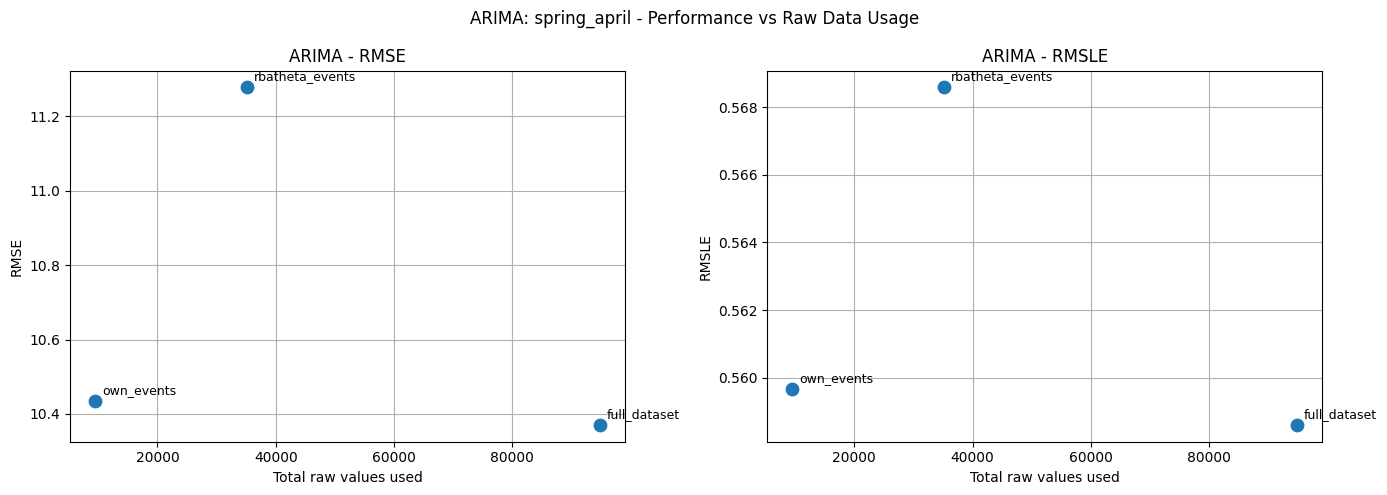

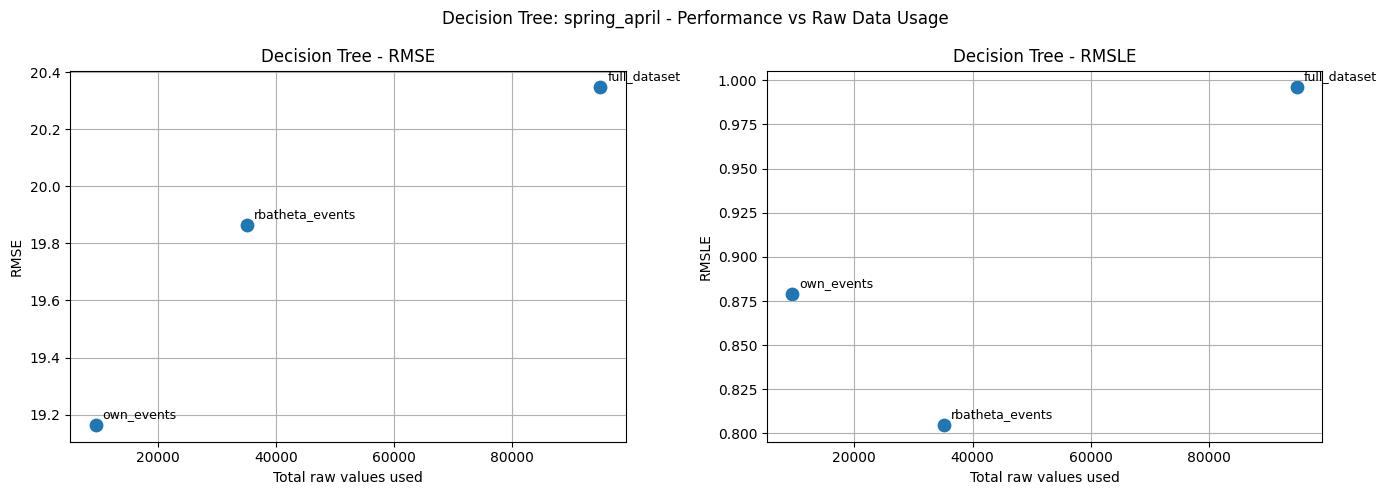

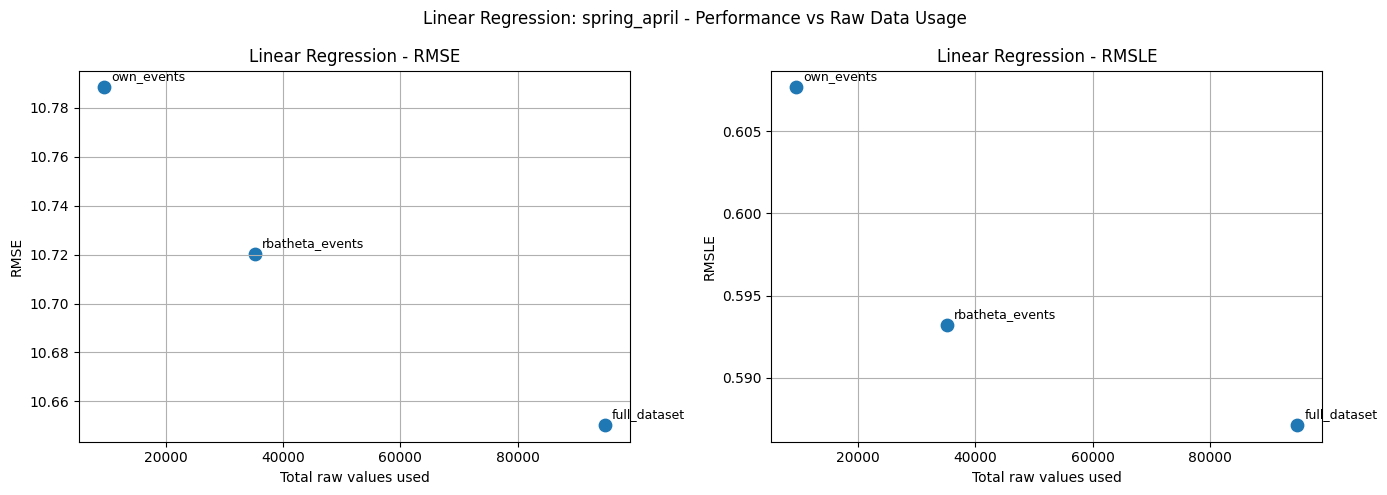

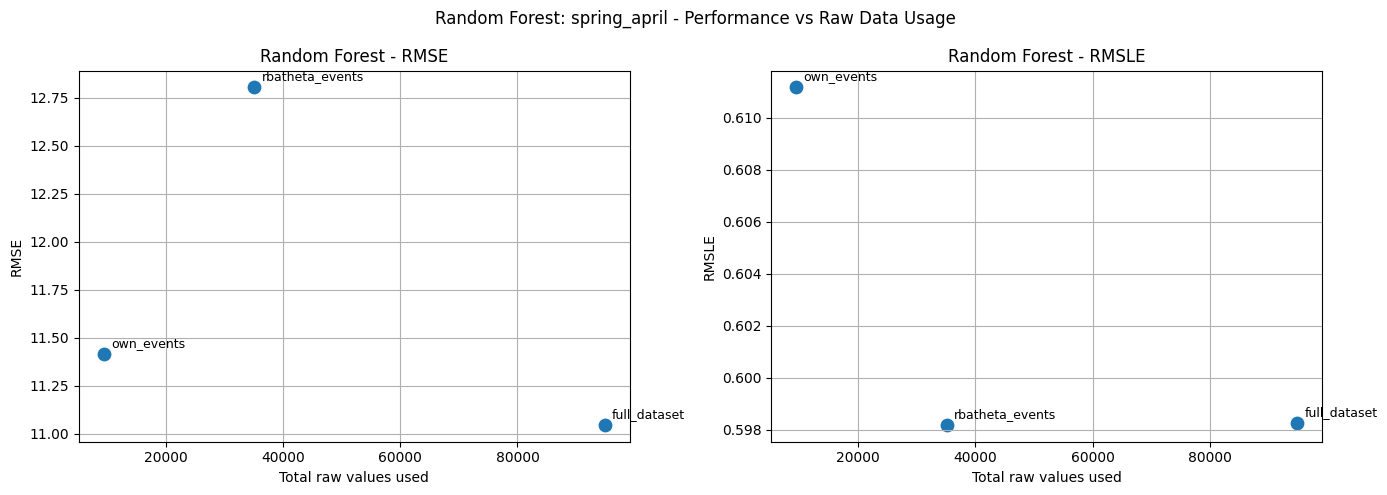

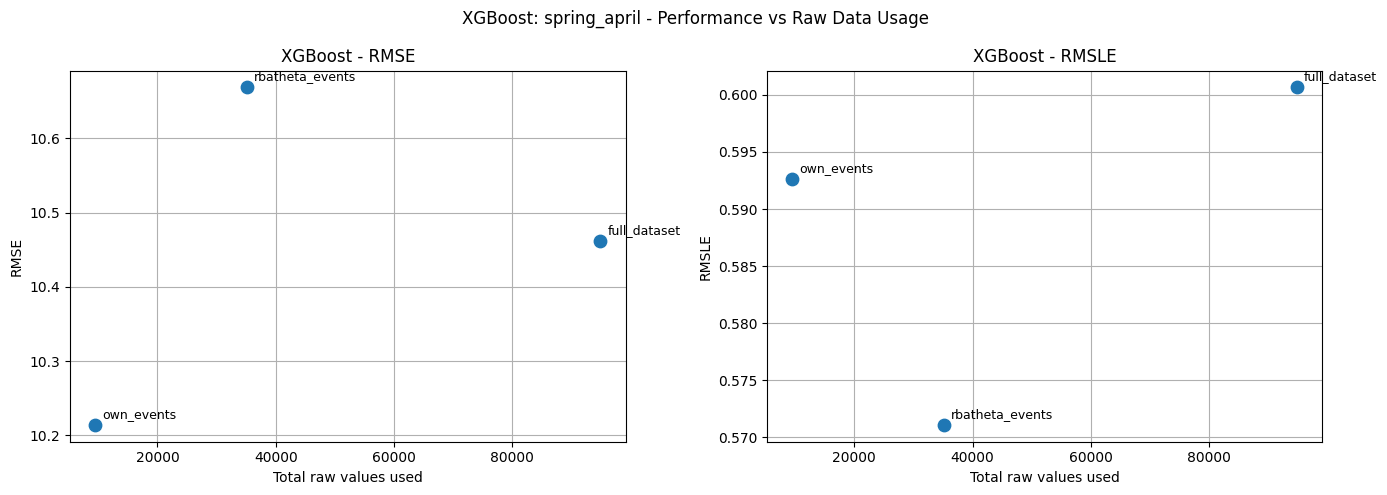


Evaluating test week: summer_june
Period: 2024-06-24 to 2024-06-30
Test shape: (168, 13)
Training model: Linear Regression
Training model: Decision Tree
Training model: Random Forest
Training model: XGBoost
Training model: ARIMA


,Test week,Test period,Model,Dataset,total_raw_values,Raw values used (%),Raw value reduction (%),RMSE,RMSLE
0,summer_june,2024-06-24 to 2024-06-30,ARIMA,own_events,9498,10.009063,89.990937,3.935885,0.402870
1,summer_june,2024-06-24 to 2024-06-30,ARIMA,rbatheta_events,35160,37.051868,62.948132,4.803949,0.393060
2,summer_june,2024-06-24 to 2024-06-30,ARIMA,full_dataset,94894,100.000000,0.000000,3.806476,0.386895
3,summer_june,2024-06-24 to 2024-06-30,Decision Tree,own_events,9498,10.009063,89.990937,15.522610,0.723026
4,summer_june,2024-06-24 to 2024-06-30,Decision Tree,rbatheta_events,35160,37.051868,62.948132,16.904919,0.907052
5,summer_june,2024-06-24 to 2024-06-30,Decision Tree,full_dataset,94894,100.000000,0.000000,18.001161,0.955295
6,summer_june,2024-06-24 to 2024-06-30,Linear Regression,own_events,9498,10.009063,89.990937,4.190253,0.468130
7,summer_june,2024-06-24 to 2024-06-30,Linear Regression,rbatheta_events,35160,37.051868,62.948132,4.136531,0.461951
8,summer_june,2024-06-24 to 2024-06-30,Linear Regression,full_dataset,94894,100.000000,0.000000,4.128573,0.457218
9,summer_june,2024-06-24 to 2024-06-30,Random Forest,own_events,9498,10.009063,89.990937,5.121294,0.421026


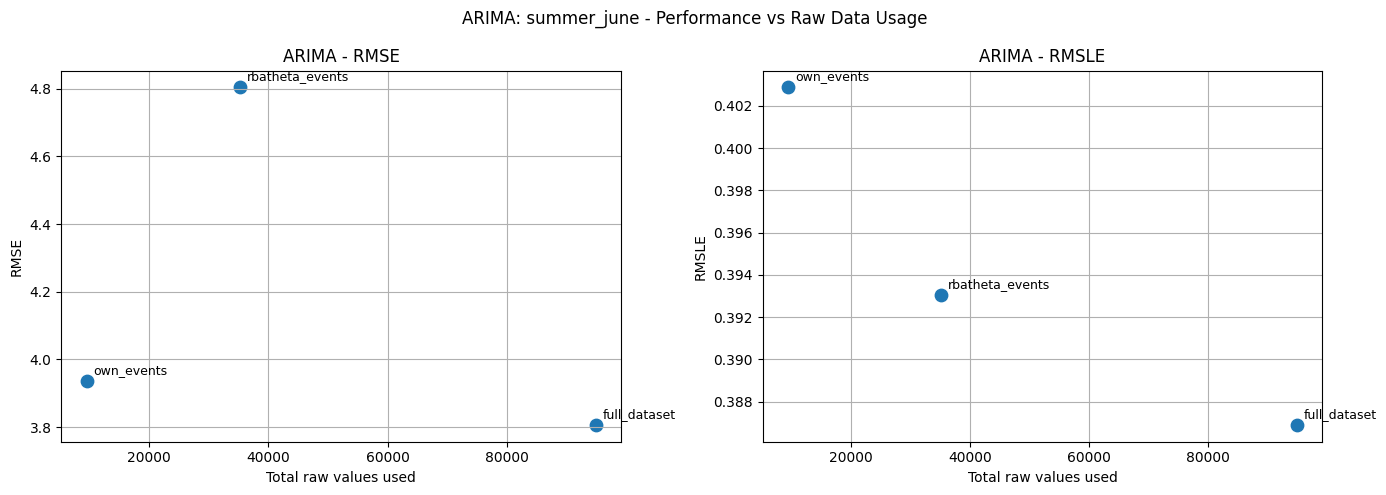

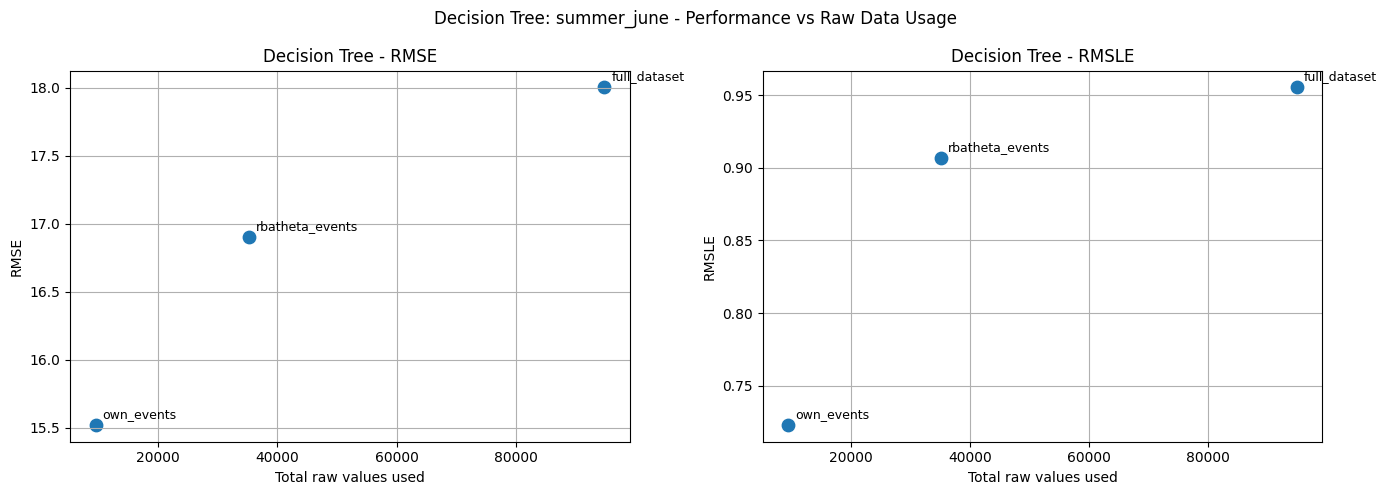

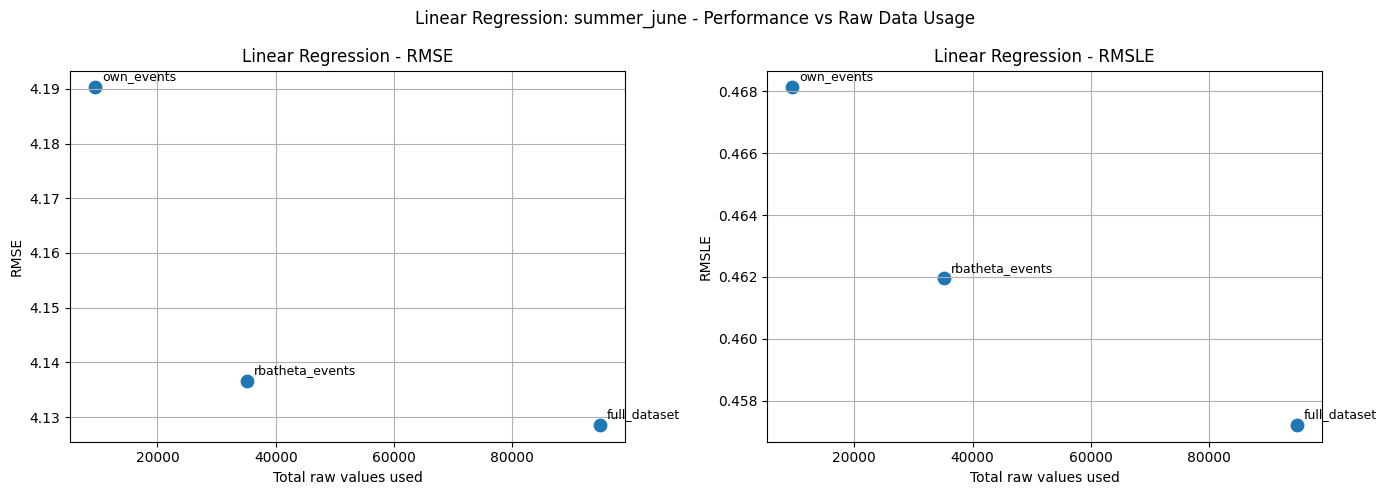

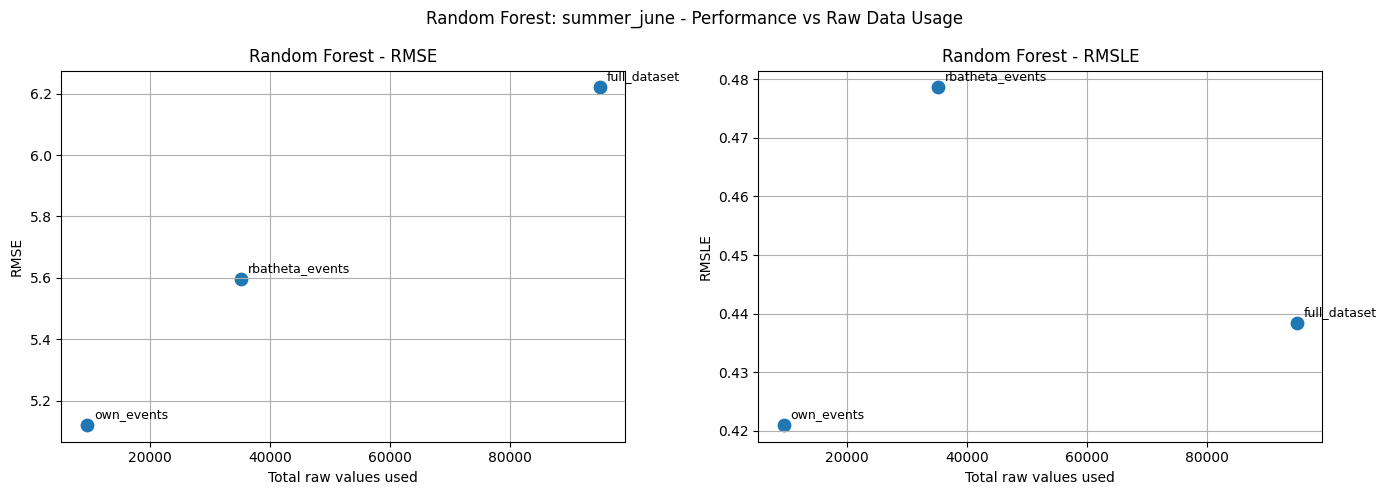

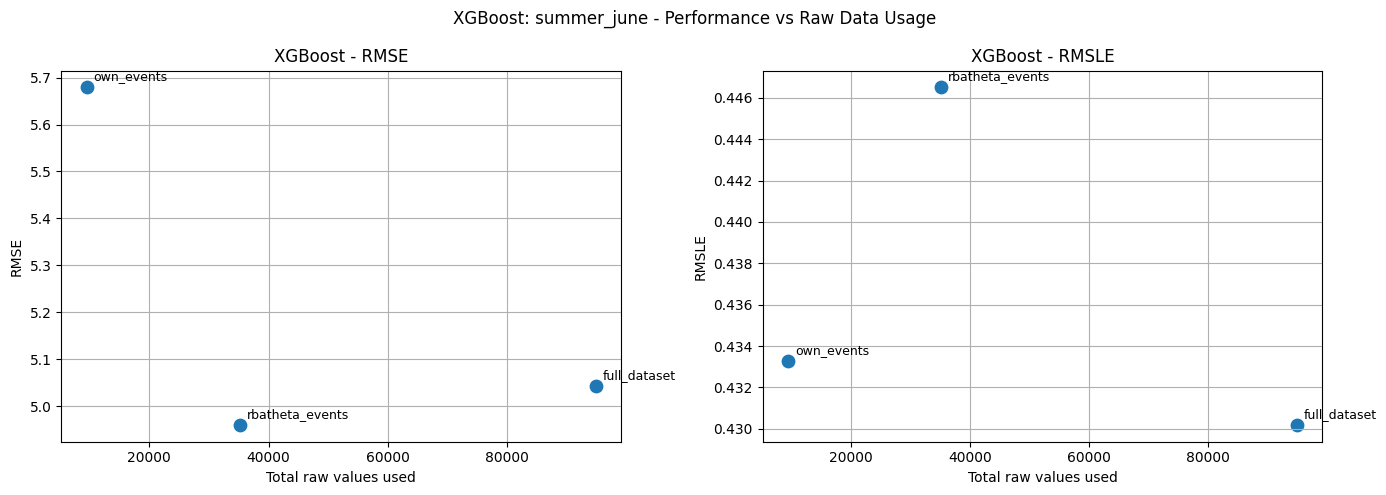


Evaluating test week: autumn_september
Period: 2024-09-16 to 2024-09-22
Test shape: (168, 13)
Training model: Linear Regression
Training model: Decision Tree
Training model: Random Forest
Training model: XGBoost
Training model: ARIMA


,Test week,Test period,Model,Dataset,total_raw_values,Raw values used (%),Raw value reduction (%),RMSE,RMSLE
0,autumn_september,2024-09-16 to 2024-09-22,ARIMA,own_events,9498,10.009063,89.990937,10.458255,0.354170
1,autumn_september,2024-09-16 to 2024-09-22,ARIMA,rbatheta_events,35160,37.051868,62.948132,11.295511,0.366192
2,autumn_september,2024-09-16 to 2024-09-22,ARIMA,full_dataset,94894,100.000000,0.000000,10.488731,0.355811
3,autumn_september,2024-09-16 to 2024-09-22,Decision Tree,own_events,9498,10.009063,89.990937,12.337993,0.435172
4,autumn_september,2024-09-16 to 2024-09-22,Decision Tree,rbatheta_events,35160,37.051868,62.948132,12.363833,0.396717
5,autumn_september,2024-09-16 to 2024-09-22,Decision Tree,full_dataset,94894,100.000000,0.000000,11.402078,0.569322
6,autumn_september,2024-09-16 to 2024-09-22,Linear Regression,own_events,9498,10.009063,89.990937,9.992021,0.287438
7,autumn_september,2024-09-16 to 2024-09-22,Linear Regression,rbatheta_events,35160,37.051868,62.948132,10.053252,0.285807
8,autumn_september,2024-09-16 to 2024-09-22,Linear Regression,full_dataset,94894,100.000000,0.000000,10.019898,0.286138
9,autumn_september,2024-09-16 to 2024-09-22,Random Forest,own_events,9498,10.009063,89.990937,9.887502,0.300612


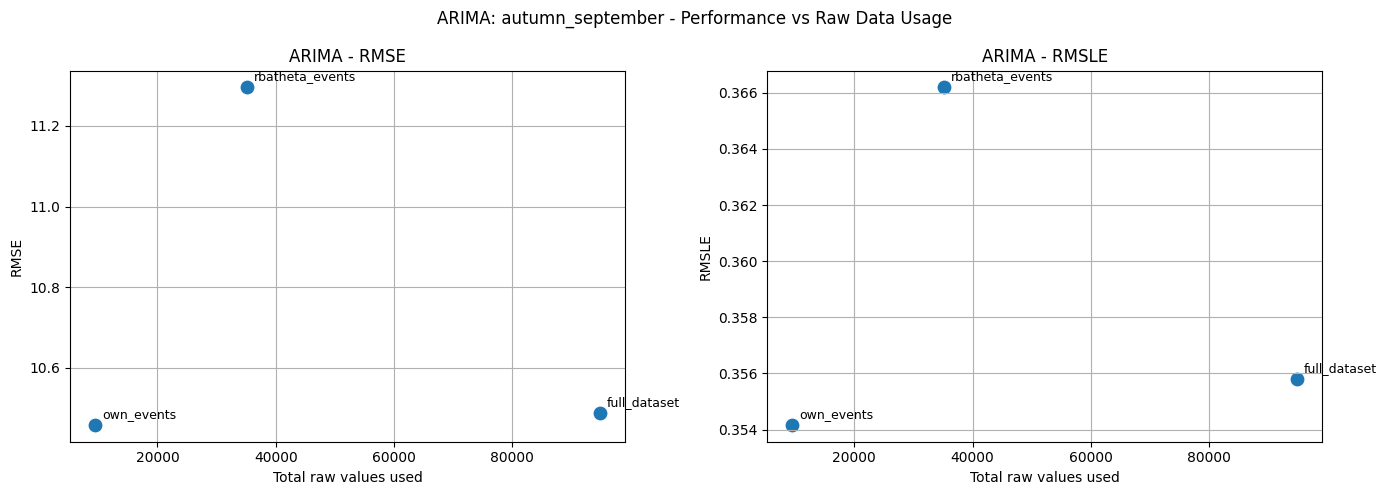

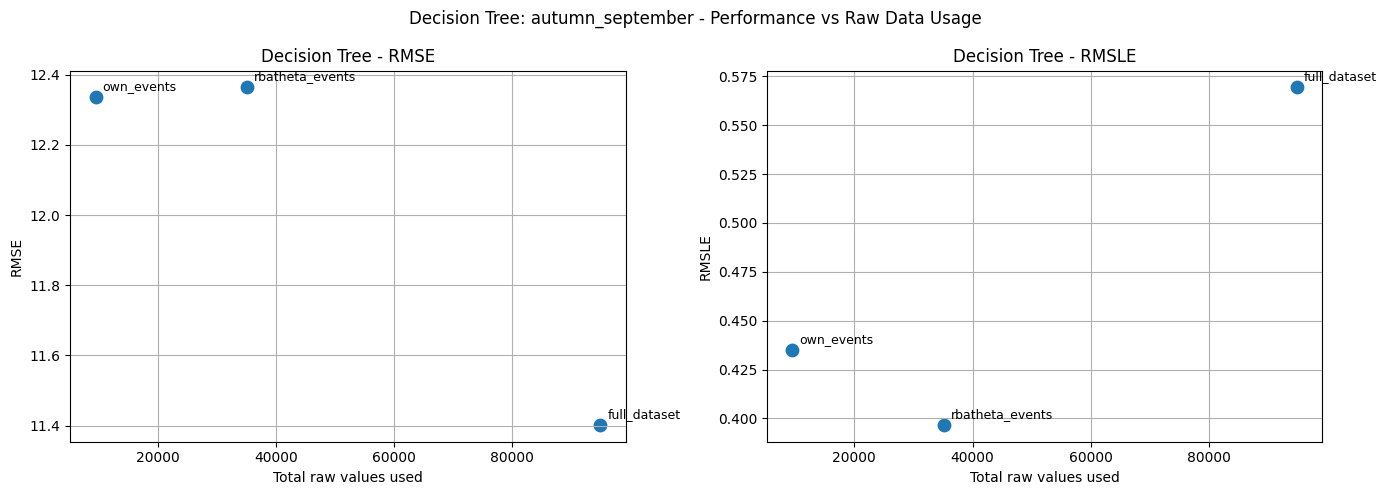

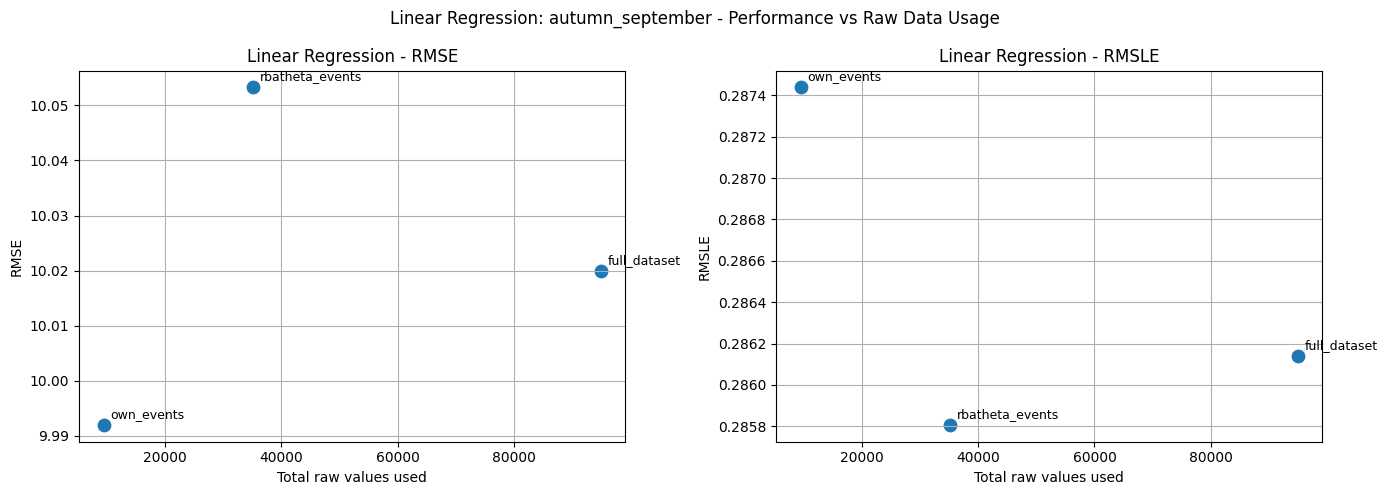

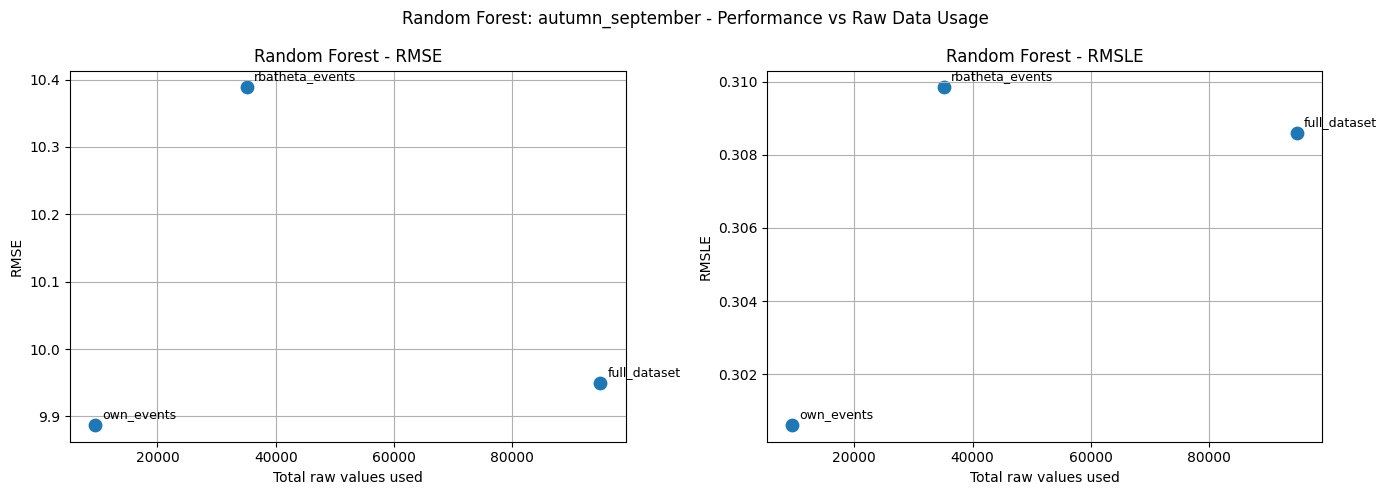

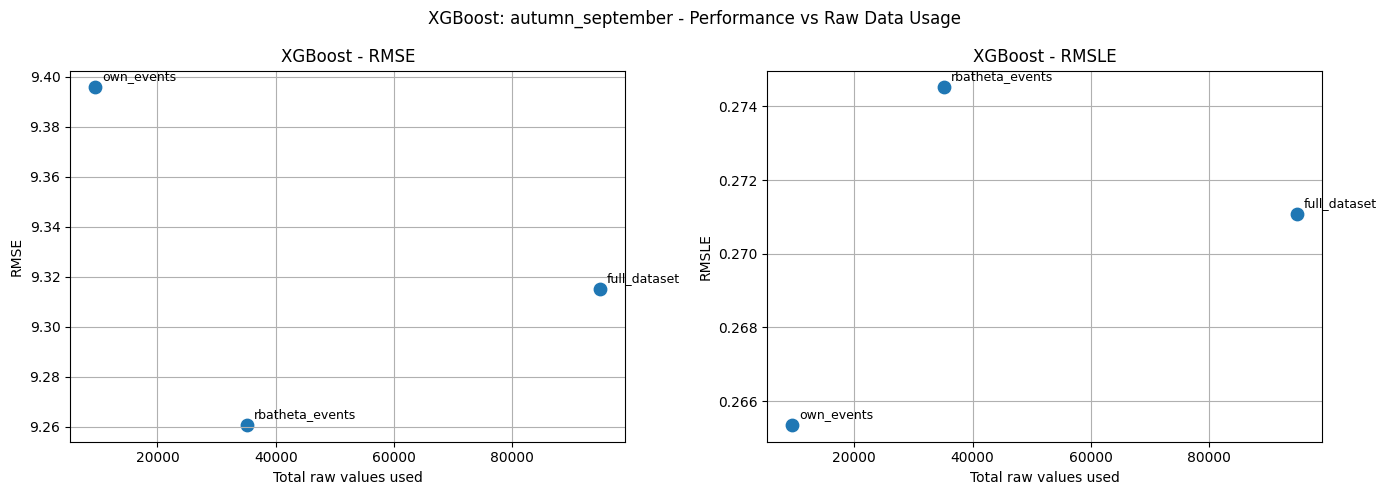


Evaluating test week: winter_december
Period: 2024-12-02 to 2024-12-08
Test shape: (167, 13)
Training model: Linear Regression
Training model: Decision Tree
Training model: Random Forest
Training model: XGBoost
Training model: ARIMA


,Test week,Test period,Model,Dataset,total_raw_values,Raw values used (%),Raw value reduction (%),RMSE,RMSLE
0,winter_december,2024-12-02 to 2024-12-08,ARIMA,own_events,9498,10.009063,89.990937,13.585388,0.164019
1,winter_december,2024-12-02 to 2024-12-08,ARIMA,rbatheta_events,35160,37.051868,62.948132,14.078111,0.181630
2,winter_december,2024-12-02 to 2024-12-08,ARIMA,full_dataset,94894,100.000000,0.000000,13.801543,0.167307
3,winter_december,2024-12-02 to 2024-12-08,Decision Tree,own_events,9498,10.009063,89.990937,19.591012,0.455169
4,winter_december,2024-12-02 to 2024-12-08,Decision Tree,rbatheta_events,35160,37.051868,62.948132,16.316965,0.290541
5,winter_december,2024-12-02 to 2024-12-08,Decision Tree,full_dataset,94894,100.000000,0.000000,15.293758,0.357991
6,winter_december,2024-12-02 to 2024-12-08,Linear Regression,own_events,9498,10.009063,89.990937,13.608588,0.160031
7,winter_december,2024-12-02 to 2024-12-08,Linear Regression,rbatheta_events,35160,37.051868,62.948132,13.699447,0.160968
8,winter_december,2024-12-02 to 2024-12-08,Linear Regression,full_dataset,94894,100.000000,0.000000,13.660777,0.160343
9,winter_december,2024-12-02 to 2024-12-08,Random Forest,own_events,9498,10.009063,89.990937,12.694735,0.154895


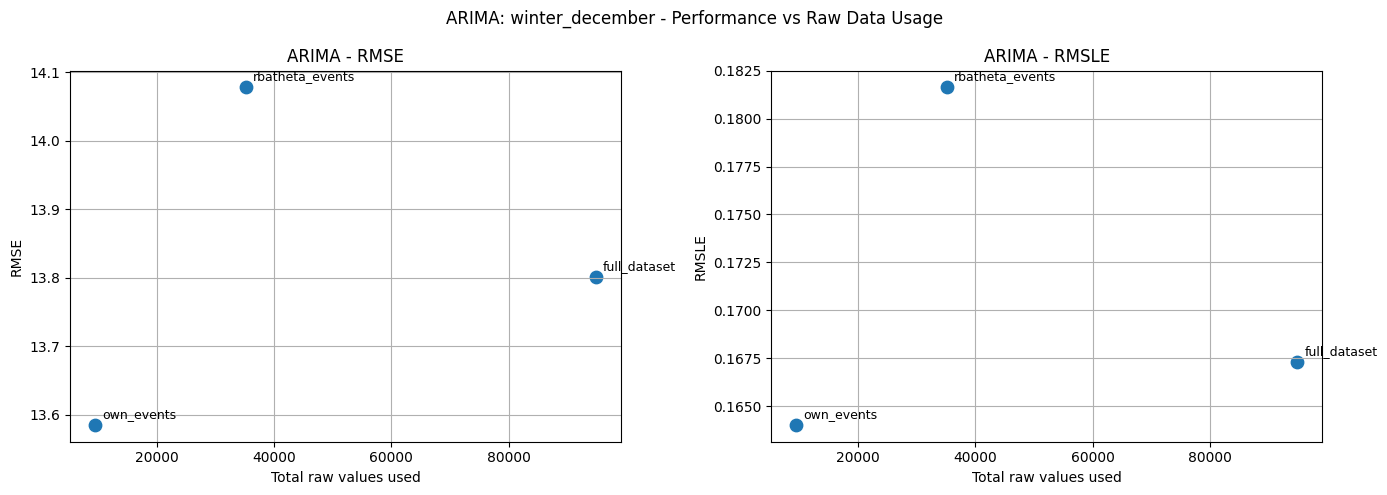

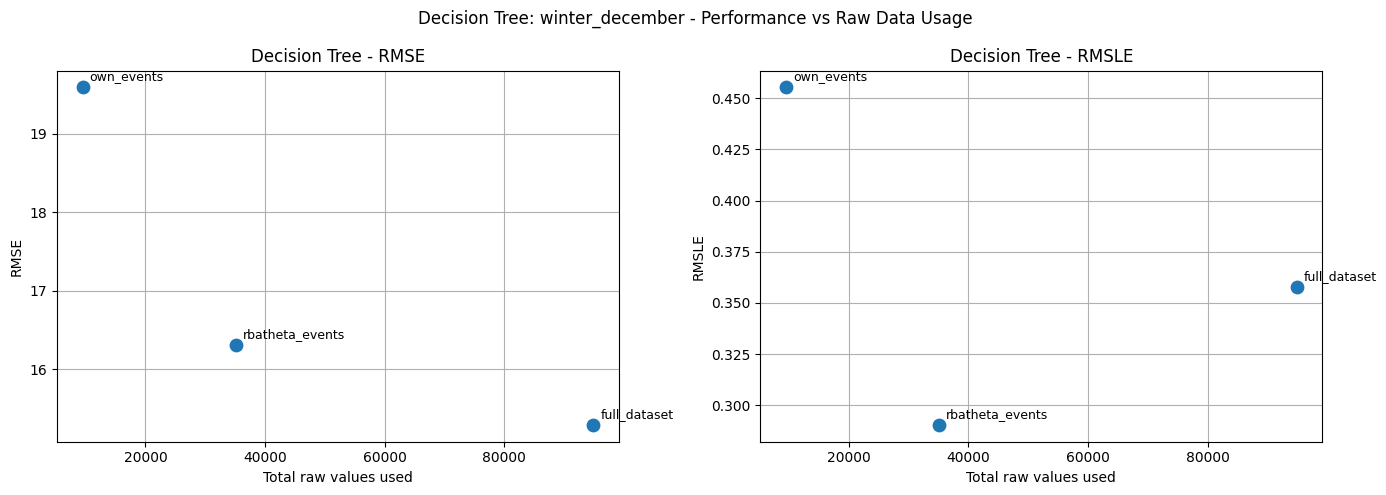

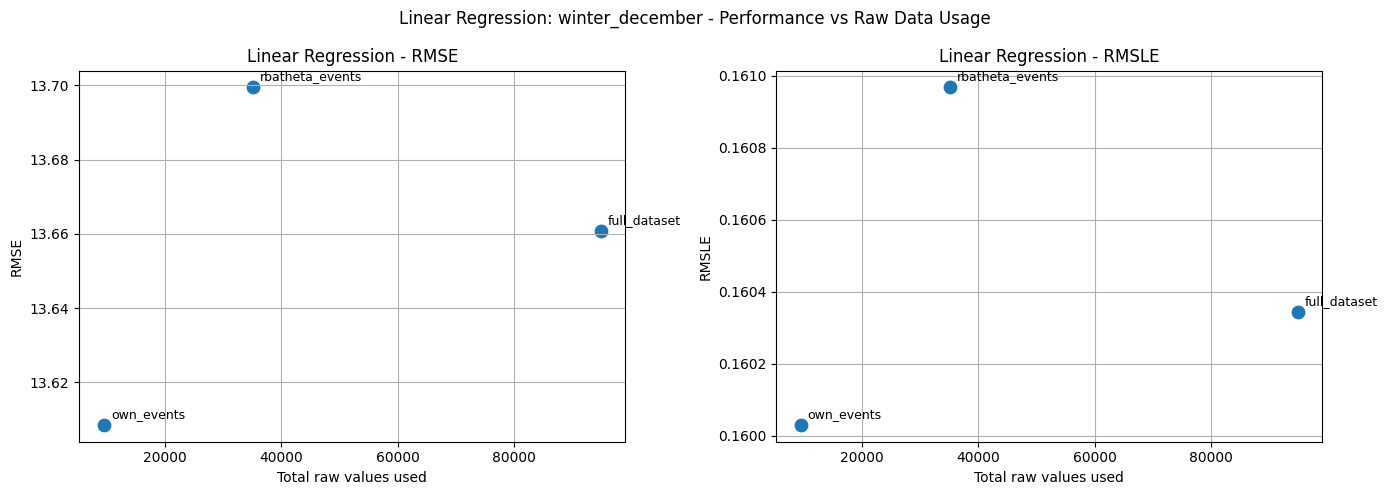

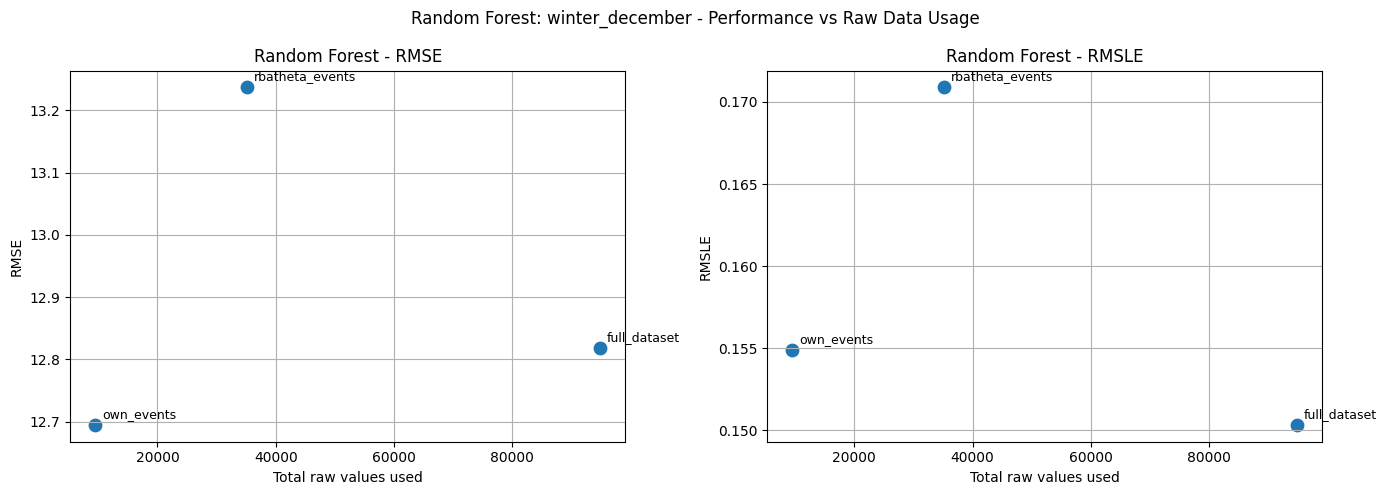

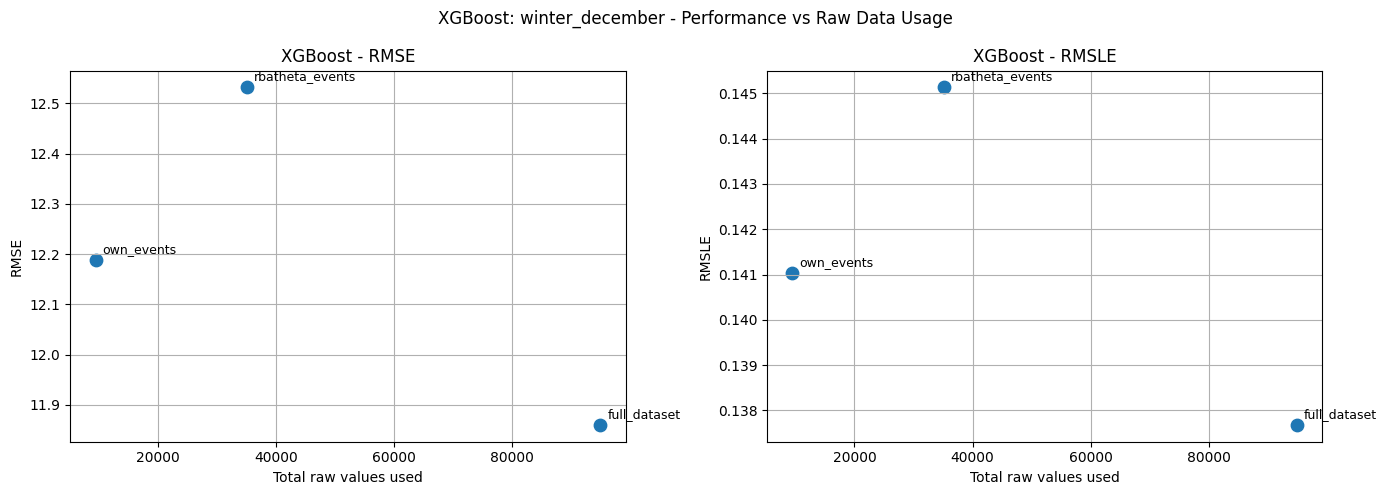

,Test week,Test period,Model,Dataset,total_raw_values,Raw values used (%),Raw value reduction (%),RMSE,RMSLE
0,winter_january,2024-01-15 to 2024-01-21,ARIMA,own_events,9498,10.009063,89.990937,10.854548,0.083745
1,winter_january,2024-01-15 to 2024-01-21,ARIMA,rbatheta_events,35160,37.051868,62.948132,10.683991,0.081211
2,winter_january,2024-01-15 to 2024-01-21,ARIMA,full_dataset,94894,100.000000,0.000000,10.520979,0.081352
3,winter_january,2024-01-15 to 2024-01-21,Decision Tree,own_events,9498,10.009063,89.990937,30.643171,0.330797
4,winter_january,2024-01-15 to 2024-01-21,Decision Tree,rbatheta_events,35160,37.051868,62.948132,27.205765,0.368877
...,...,...,...,...,...,...,...,...,...
70,winter_december,2024-12-02 to 2024-12-08,Random Forest,rbatheta_events,35160,37.051868,62.948132,13.236724,0.170881
71,winter_december,2024-12-02 to 2024-12-08,Random Forest,full_dataset,94894,100.000000,0.000000,12.818144,0.150329
72,winter_december,2024-12-02 to 2024-12-08,XGBoost,own_events,9498,10.009063,89.990937,12.187304,0.141033
73,winter_december,2024-12-02 to 2024-12-08,XGBoost,rbatheta_events,35160,37.051868,62.948132,12.531571,0.145131


In [135]:
# ============================================================
# STEP 12-15 - EVALUATE FIVE TEST WEEKS, SAVE TABLES AND PLOTS
# ============================================================

import shutil
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Experiment output folder
# ------------------------------------------------------------

def clean_date(date_str):
    return date_str.replace("-", "")

experiment_name = (
    f"{zone_code}_"
    f"cal{clean_date(calibration_start)}-{clean_date(calibration_end)}_"
    f"train{clean_date(train_start)}-{clean_date(train_end)}_"
    f"5weeks2024_"
    f"raw_values_event_comparison"
)

results_dir = (
    project_root
    / "results"
    / "event_training_comparison"
    / experiment_name
)

plots_root = results_dir / "plots"
tables_root = results_dir / "tables"
predictions_root = results_dir / "predictions"

for folder in [plots_root, tables_root, predictions_root]:
    if folder.exists():
        shutil.rmtree(folder)
    folder.mkdir(parents=True, exist_ok=True)

print("Saving experiment in:")
print(results_dir)

# ------------------------------------------------------------
# Save global data usage table
# ------------------------------------------------------------

data_usage_table.to_csv(
    tables_root / "data_usage_table.csv",
    index=False,
)

data_usage_table.to_excel(
    tables_root / "data_usage_table.xlsx",
    index=False,
)

# ------------------------------------------------------------
# Model configuration
# ------------------------------------------------------------

models = etc.get_default_models()

feature_cols = [
    "price_value",
    "buy_volume_value",
    "sell_volume_value",
    "hour_of_day",
    "day_of_week",
    "month",
]

feature_cols = [
    col for col in feature_cols
    if col in df_train_full_final.columns
]

target_col = "target_price_1h"

# ARIMA can be very slow if True because it is rolling ARIMA.
RUN_ARIMA = True
ARIMA_ORDER = (1, 0, 1)

all_week_results = []

# ------------------------------------------------------------
# Evaluation loop
# ------------------------------------------------------------

for week in test_weeks:

    test_name = week["test_name"]
    week_test_start = week["test_start"]
    week_test_end = week["test_end"]

    print("\n" + "=" * 70)
    print(f"Evaluating test week: {test_name}")
    print(f"Period: {week_test_start} to {week_test_end}")
    print("=" * 70)

    week_dir = results_dir / test_name
    week_tables_dir = week_dir / "tables"
    week_plots_dir = week_dir / "plots"
    week_predictions_dir = week_dir / "predictions"

    week_tables_dir.mkdir(parents=True, exist_ok=True)
    week_plots_dir.mkdir(parents=True, exist_ok=True)
    week_predictions_dir.mkdir(parents=True, exist_ok=True)

    # ----------------------------
    # Build test dataset
    # ----------------------------

    df_test_common = build_test_week_dataset(
        df_model=df_model_test,
        test_start=week_test_start,
        test_end=week_test_end,
    )

    print("Test shape:", df_test_common.shape)

    if df_test_common.empty:
        print(f"WARNING: empty test dataset for {test_name}. Skipping.")
        continue

    # ----------------------------
    # Train/evaluate ML models
    # ----------------------------

    all_results = []
    all_predictions = {}

    for model_name, model_factory in models.items():

        print(f"Training model: {model_name}")

        model_results, model_predictions = etc.train_single_model_with_training_sets(
            model_name=model_name,
            model_factory=model_factory,
            train_datasets=train_datasets,
            df_test=df_test_common,
            feature_cols=feature_cols,
            target_col=target_col,
            full_train_size=len(df_train_full_final),
        )

        all_results.extend(model_results)
        all_predictions[model_name] = model_predictions

    # ----------------------------
    # Train/evaluate ARIMA
    # ----------------------------

    if RUN_ARIMA:
        print("Training model: ARIMA")

        arima_results, arima_predictions = etc.train_arima_with_training_sets(
            train_datasets=train_datasets,
            df_test=df_test_common,
            target_col=target_col,
            full_train_size=len(df_train_full_final),
            arima_order=ARIMA_ORDER,
        )

        all_results.extend(arima_results)
        all_predictions["ARIMA"] = arima_predictions

    # ----------------------------
    # Performance table
    # ----------------------------

    performance_table = pd.DataFrame(all_results)

    performance_table = performance_table.rename(columns={
        "model": "Model",
        "training_dataset": "Dataset",
        "RMSE": "RMSE",
        "RMSLE": "RMSLE",
    })

    performance_table = performance_table[
        [
            "Model",
            "Dataset",
            "RMSE",
            "RMSLE",
        ]
    ].copy()

    performance_table["Test week"] = test_name
    performance_table["Test period"] = f"{week_test_start} to {week_test_end}"

    # ----------------------------
    # Merge with raw data usage
    # ----------------------------

    performance_table_for_merge = performance_table.copy()

    performance_table_for_merge["Dataset"] = performance_table_for_merge["Dataset"].replace({
        "full_prices": "full_dataset",
    })

    performance_vs_data_table = performance_table_for_merge.merge(
        data_usage_table[
            [
                "Dataset",
                "total_raw_values",
                "Raw values used (%)",
                "Raw value reduction (%)",
            ]
        ],
        on="Dataset",
        how="left",
    )

    performance_vs_data_table = performance_vs_data_table[
        [
            "Test week",
            "Test period",
            "Model",
            "Dataset",
            "total_raw_values",
            "Raw values used (%)",
            "Raw value reduction (%)",
            "RMSE",
            "RMSLE",
        ]
    ]

    performance_vs_data_table = performance_vs_data_table.sort_values(
        ["Model", "total_raw_values"]
    ).reset_index(drop=True)

    display(performance_vs_data_table)

    all_week_results.append(performance_vs_data_table)

    # ----------------------------
    # Save week tables
    # ----------------------------

    performance_vs_data_table.to_csv(
        week_tables_dir / f"{test_name}_performance_vs_data.csv",
        index=False,
    )

    performance_vs_data_table.to_excel(
        week_tables_dir / f"{test_name}_performance_vs_data.xlsx",
        index=False,
    )

    # ----------------------------
    # Save predictions
    # ----------------------------

    for model_name, model_predictions in all_predictions.items():
        for dataset_name, pred_df in model_predictions.items():

            safe_model_name = model_name.replace(" ", "_").replace("/", "_")
            safe_dataset_name = dataset_name.replace(" ", "_").replace("/", "_")

            pred_path = (
                week_predictions_dir
                / f"{test_name}_{safe_model_name}_{safe_dataset_name}_predictions.csv"
            )

            pred_df.to_csv(pred_path, index=False)

    # ----------------------------
    # Save plots for this week
    # ----------------------------

    plot_df = performance_vs_data_table.copy()

    for model_name in plot_df["Model"].unique():

        df_model = plot_df[
            plot_df["Model"] == model_name
        ].copy()

        df_model = df_model.sort_values("total_raw_values")

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # RMSE
        axes[0].scatter(
            df_model["total_raw_values"],
            df_model["RMSE"],
            s=80,
        )

        for _, row in df_model.iterrows():
            axes[0].annotate(
                row["Dataset"],
                (row["total_raw_values"], row["RMSE"]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9,
            )

        axes[0].set_xlabel("Total raw values used")
        axes[0].set_ylabel("RMSE")
        axes[0].set_title(f"{model_name} - RMSE")
        axes[0].grid(True)

        # RMSLE
        axes[1].scatter(
            df_model["total_raw_values"],
            df_model["RMSLE"],
            s=80,
        )

        for _, row in df_model.iterrows():
            axes[1].annotate(
                row["Dataset"],
                (row["total_raw_values"], row["RMSLE"]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9,
            )

        axes[1].set_xlabel("Total raw values used")
        axes[1].set_ylabel("RMSLE")
        axes[1].set_title(f"{model_name} - RMSLE")
        axes[1].grid(True)

        plt.suptitle(f"{model_name}: {test_name} - Performance vs Raw Data Usage")
        plt.tight_layout()

        safe_model_name = model_name.replace(" ", "_").replace("/", "_")

        plot_path = week_plots_dir / f"{test_name}_{safe_model_name}_raw_values_vs_performance.png"

        plt.savefig(
            plot_path,
            dpi=300,
            bbox_inches="tight",
        )

        plt.show()

# ------------------------------------------------------------
# Combine all weeks
# ------------------------------------------------------------

all_weeks_results_table = pd.concat(
    all_week_results,
    ignore_index=True,
)

all_weeks_results_table.to_csv(
    tables_root / "all_weeks_performance_vs_data.csv",
    index=False,
)

all_weeks_results_table.to_excel(
    tables_root / "all_weeks_performance_vs_data.xlsx",
    index=False,
)

all_weeks_results_table

In [136]:
# ============================================================
# STEP 16 - AVERAGE PERFORMANCE TABLE ACROSS FIVE WEEKS
# ============================================================

average_performance_table = (
    all_weeks_results_table
    .groupby(
        [
            "Model",
            "Dataset",
            "total_raw_values",
            "Raw values used (%)",
            "Raw value reduction (%)",
        ],
        as_index=False,
    )
    .agg(
        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),
        RMSLE_mean=("RMSLE", "mean"),
        RMSLE_std=("RMSLE", "std"),
    )
)

average_performance_table = average_performance_table.sort_values(
    ["Model", "total_raw_values"]
).reset_index(drop=True)

average_performance_table.to_csv(
    tables_root / "average_performance_5weeks.csv",
    index=False,
)

average_performance_table.to_excel(
    tables_root / "average_performance_5weeks.xlsx",
    index=False,
)

average_performance_table

,Model,Dataset,total_raw_values,Raw values used (%),Raw value reduction (%),RMSE_mean,RMSE_std,RMSLE_mean,RMSLE_std
0,ARIMA,own_events,9498,10.009063,89.990937,9.854008,3.558520,0.312895,0.190638
1,ARIMA,rbatheta_events,35160,37.051868,62.948132,10.427747,3.409269,0.318137,0.190668
2,ARIMA,full_dataset,94894,100.000000,0.000000,9.797712,3.648789,0.309993,0.188716
3,Decision Tree,own_events,9498,10.009063,89.990937,19.451815,6.917254,0.564683,0.227757
4,Decision Tree,rbatheta_events,35160,37.051868,62.948132,18.531036,5.536417,0.553613,0.281071
5,Decision Tree,full_dataset,94894,100.000000,0.000000,19.729654,8.439807,0.670938,0.288397
6,Linear Regression,own_events,9498,10.009063,89.990937,10.329340,3.750460,0.326415,0.209614
7,Linear Regression,rbatheta_events,35160,37.051868,62.948132,10.274183,3.736204,0.320755,0.205448
8,Linear Regression,full_dataset,94894,100.000000,0.000000,10.248055,3.732382,0.318527,0.202738
9,Random Forest,own_events,9498,10.009063,89.990937,11.280979,4.415554,0.335075,0.186412


In [139]:
presentation_table = average_performance_table[
    [
        "Model",
        "Dataset",
        "RMSE_mean",
        "RMSLE_mean",
    ]
].copy()

presentation_table["RMSE_mean"] = presentation_table["RMSE_mean"].round(3)
presentation_table["RMSLE_mean"] = presentation_table["RMSLE_mean"].round(3)

presentation_table

,Model,Dataset,RMSE_mean,RMSLE_mean
0,ARIMA,own_events,9.854,0.313
1,ARIMA,rbatheta_events,10.428,0.318
2,ARIMA,full_dataset,9.798,0.310
3,Decision Tree,own_events,19.452,0.565
4,Decision Tree,rbatheta_events,18.531,0.554
5,Decision Tree,full_dataset,19.730,0.671
6,Linear Regression,own_events,10.329,0.326
7,Linear Regression,rbatheta_events,10.274,0.321
8,Linear Regression,full_dataset,10.248,0.319
9,Random Forest,own_events,11.281,0.335


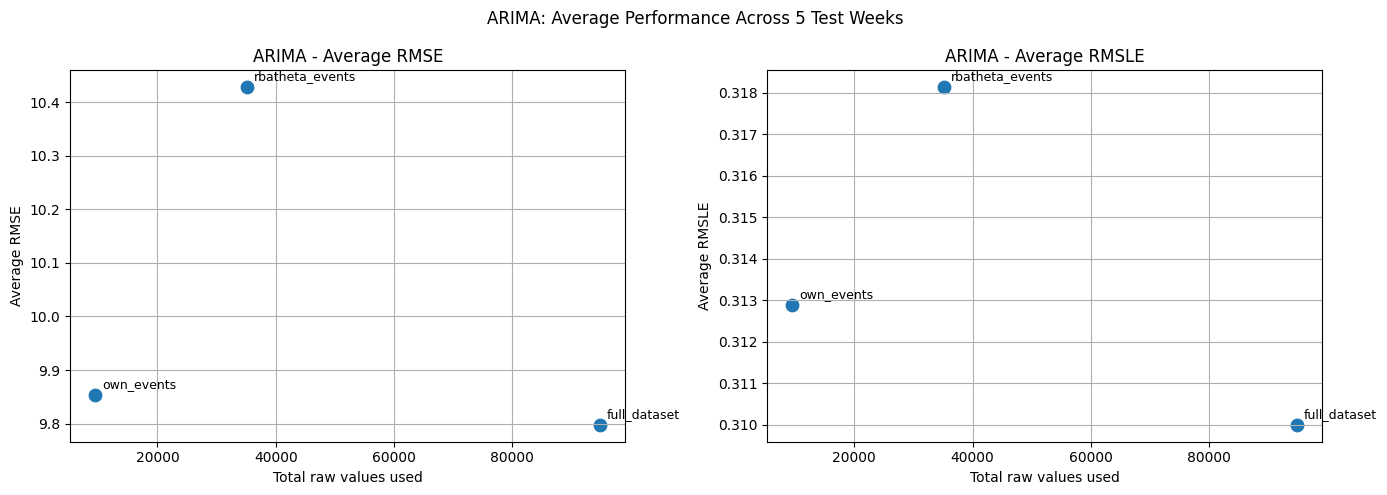

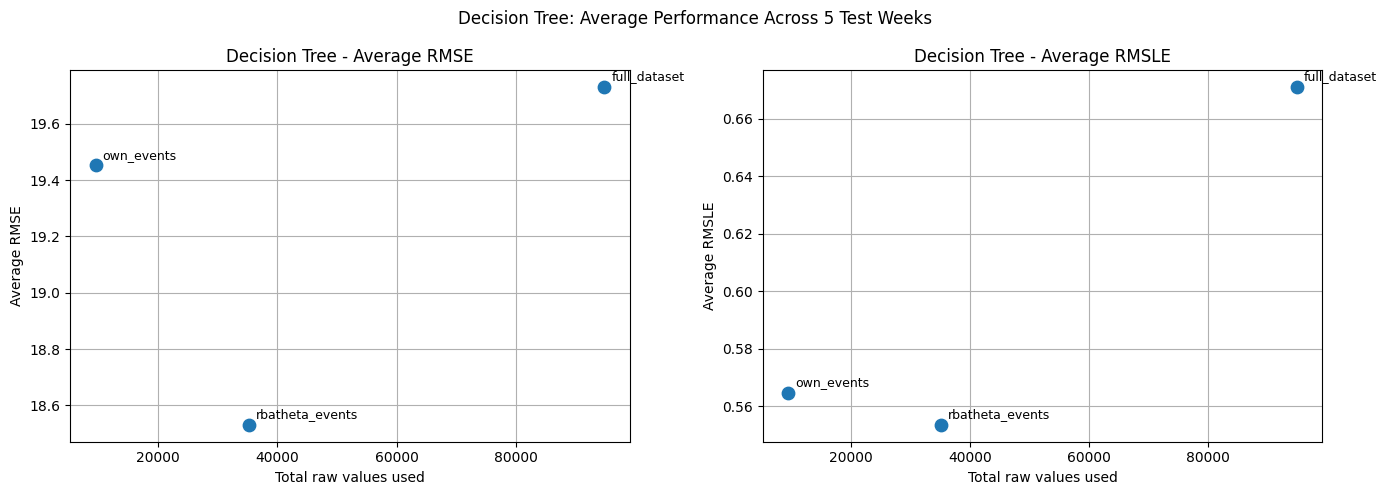

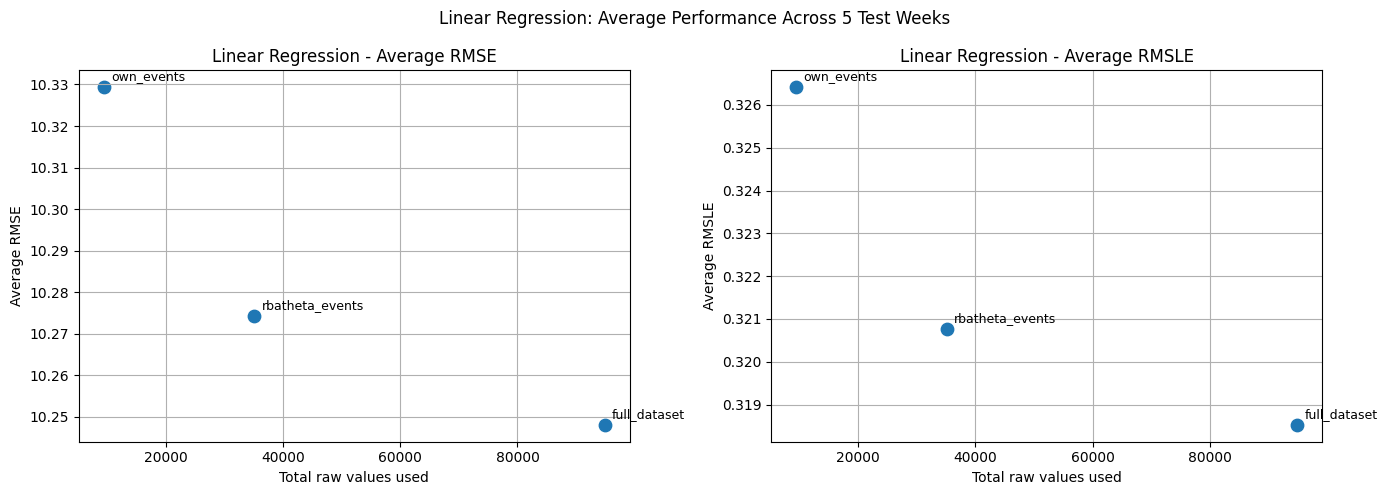

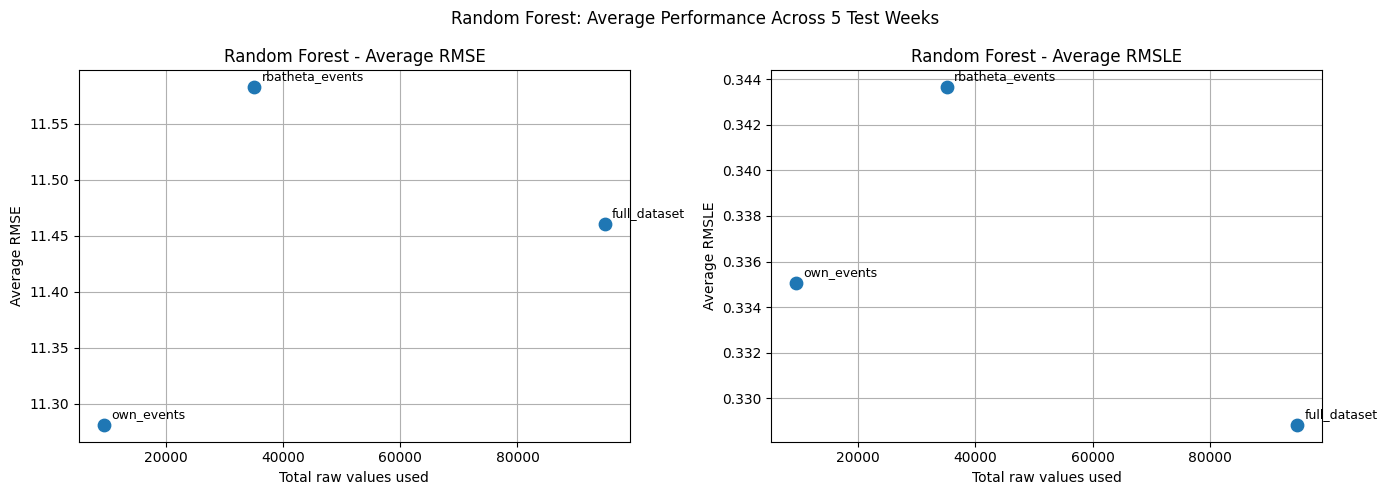

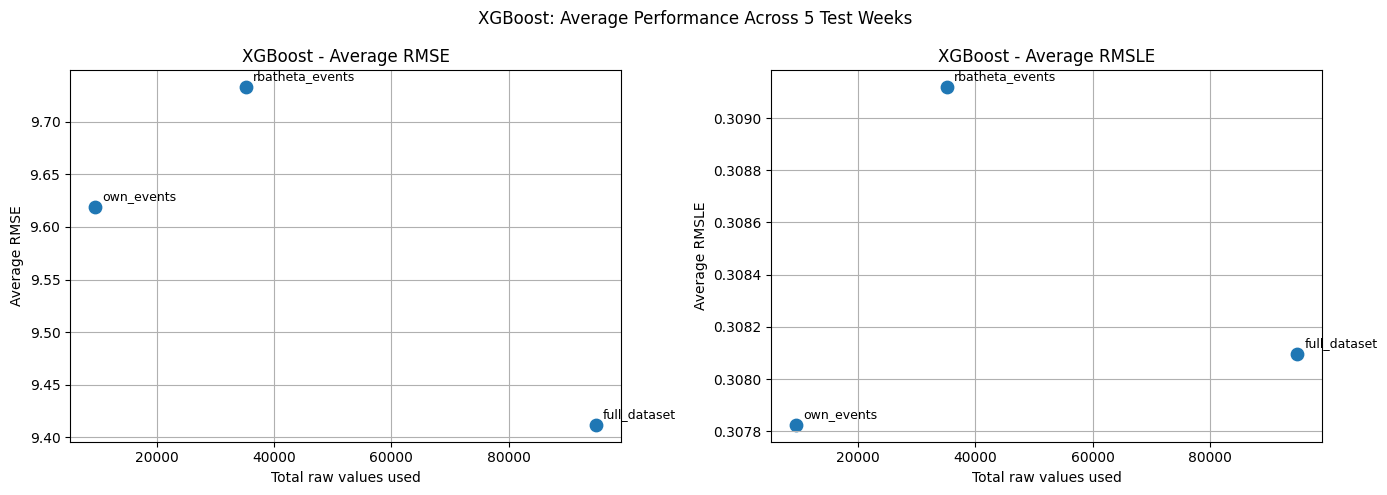

In [137]:
# ============================================================
# STEP 17 - AVERAGE PERFORMANCE PLOTS
# ============================================================

avg_plots_dir = plots_root / "average_5weeks"
avg_plots_dir.mkdir(parents=True, exist_ok=True)

plot_df = average_performance_table.copy()

for model_name in plot_df["Model"].unique():

    df_model = plot_df[
        plot_df["Model"] == model_name
    ].copy()

    df_model = df_model.sort_values("total_raw_values")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # RMSE mean
    axes[0].scatter(
        df_model["total_raw_values"],
        df_model["RMSE_mean"],
        s=80,
    )

    for _, row in df_model.iterrows():
        axes[0].annotate(
            row["Dataset"],
            (row["total_raw_values"], row["RMSE_mean"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9,
        )

    axes[0].set_xlabel("Total raw values used")
    axes[0].set_ylabel("Average RMSE")
    axes[0].set_title(f"{model_name} - Average RMSE")
    axes[0].grid(True)

    # RMSLE mean
    axes[1].scatter(
        df_model["total_raw_values"],
        df_model["RMSLE_mean"],
        s=80,
    )

    for _, row in df_model.iterrows():
        axes[1].annotate(
            row["Dataset"],
            (row["total_raw_values"], row["RMSLE_mean"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9,
        )

    axes[1].set_xlabel("Total raw values used")
    axes[1].set_ylabel("Average RMSLE")
    axes[1].set_title(f"{model_name} - Average RMSLE")
    axes[1].grid(True)

    plt.suptitle(f"{model_name}: Average Performance Across 5 Test Weeks")
    plt.tight_layout()

    safe_model_name = model_name.replace(" ", "_").replace("/", "_")

    plot_path = avg_plots_dir / f"{safe_model_name}_average_raw_values_vs_performance.png"

    plt.savefig(
        plot_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()